# Metrics Pipeline

Computes the core benchmark metrics over the LLM recommendations: diversity, parity, factuality, consistency, and duplicates.

# Metrics Pipeline

Plots the per-call benchmark metrics over the LLM recommendations: diversity, parity, factuality, consistency, duplicates, connectedness and similarity.

The compute step lives in `code/scripts/metrics/build_valid_calls.py`; this notebook just loads its output and plots.

Connectedness and similarity (paper Eqs. 6-8) ride along in the `social` metric group, so every plot below already includes them. See the diagnostic section at the end for their coverage.

In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

sys.path.insert(0, '../..')
%reload_ext autoreload
%autoreload 2

from libs.visuals.vis import sns_paper_style
from libs.visuals.grouped_metrics import plot_grouped_metrics
from libs.visuals.grouped_metrics import plot_grouped_metrics_labeled
from libs.visuals.quadrant_scatter import plot_quadrant_scatter
from libs.visuals.sankey import plot_sankey, collapse_tail, normalize_by_source

from libs.metrics.aggregators import aggregate_scores
from libs.metrics.utils import *
from libs.metrics.constants import *
from libs.metrics.constants import LOCATION_ORDER as LOCATION_ISO_ORDER
from libs.visuals.constants import *
from libs.utils import ios
from libs.utils.config import get_results_path


In [3]:
RESULTS = get_results_path()
DATA = RESULTS.parent / 'data'

VALID_CALLS_PATH = RESULTS / 'factualities/tables/valid_requests_metadata.csv'
PLOTS_DIR = RESULTS / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CONTEXT_PROMPT_METADATA_FN = DATA / 'context/english/input.json'
MODELS_METADATA_FN = DATA / 'models/metadata.json'
MODELS_FN = DATA / 'models/models.txt'

MODELS = ios.read_list_from_file(MODELS_FN)
models_metadata = ios.load_json(MODELS_METADATA_FN)
field_metadata = ios.load_json(CONTEXT_PROMPT_METADATA_FN)
SUBFIELD_ORDER = [sf for f in FIELD_ORDER for fobj in field_metadata['fields'] if fobj['field']==f for sf in fobj['subfields']]

FIG_WIDTH = FIG_WIDTH_PAPER
FIG_HEIGHT = FIG_HEIGHT_PAPER
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT)


# Plots

In [ ]:
df_valid_calls = pd.read_csv(VALID_CALLS_PATH, index_col=False)

def _pct_tier_last(c):
    parts = c.split('_')
    if c.startswith('pct_') and len(parts) == 3 and parts[1] in ('low', 'med', 'high'):
        return f"{parts[0]}_{parts[2]}_{parts[1]}"
    return c
df_valid_calls = df_valid_calls.rename(columns=_pct_tier_last)

# Idempotent: factuality_location -> bias_location (issue #36). CSVs built before
# the rename still carry the old column name; ones built after are left untouched.
df_valid_calls = df_valid_calls.rename(columns=METRIC_RENAME_MAP)

print(f'Loaded {len(df_valid_calls):,} rows × {len(df_valid_calls.columns)} columns from {VALID_CALLS_PATH}')

In [5]:
df_valid_calls.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,model_access,model_size,model_class,model_family,model_short_name,validity,refusals,n_total_recommendations,n_unique_authors,n_authors_found,...,pct_works_high,div_productivity_works,pct_citations_low,pct_citations_med,pct_citations_high,div_productivity_citations,parity_works,parity_citations,popularity_works,popularity_citations,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,open-weight,M,True,deepseek,deepseek-r1-32,1,0,1.0000,1.0000,1.0000,...,1.0000,NaN,0.0000,0.0000,1.0000,NaN,0.3333,0.3333,1.0000,1.0000,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0000,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,open-weight,M,True,deepseek,deepseek-r1-32,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1250,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


In [6]:
sns_paper_style(font_scale=1.55)

In [7]:

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
_removed = 0
for _old in PLOTS_DIR.glob('*.pdf'):
    _old.unlink()
    _removed += 1
print(f'Cleared {PLOTS_DIR} — {_removed} stale PDF(s) removed')

Cleared /code/asanchez/LLMScholar-Personas/results/plots — 0 stale PDF(s) removed


## RQ1 & RQ2

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_stacked.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_stacked.pdf


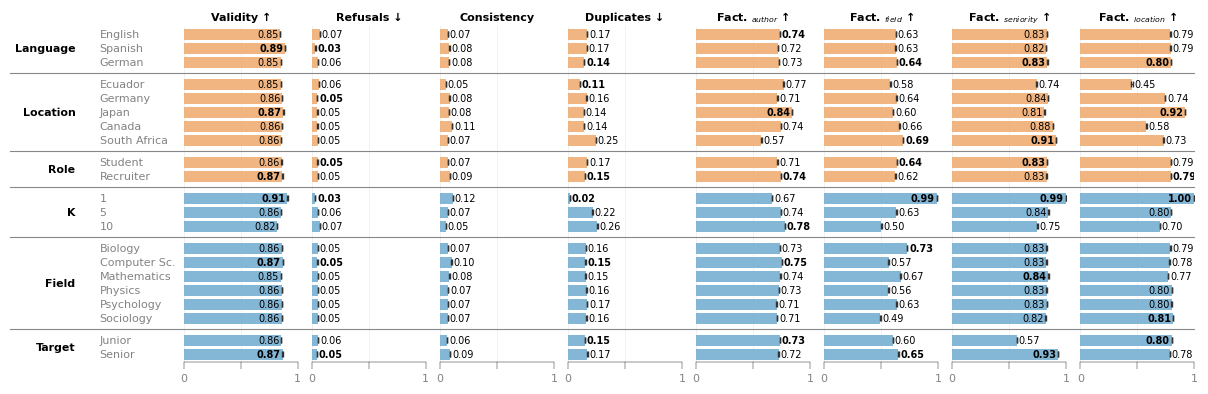

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_stacked.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_stacked.pdf


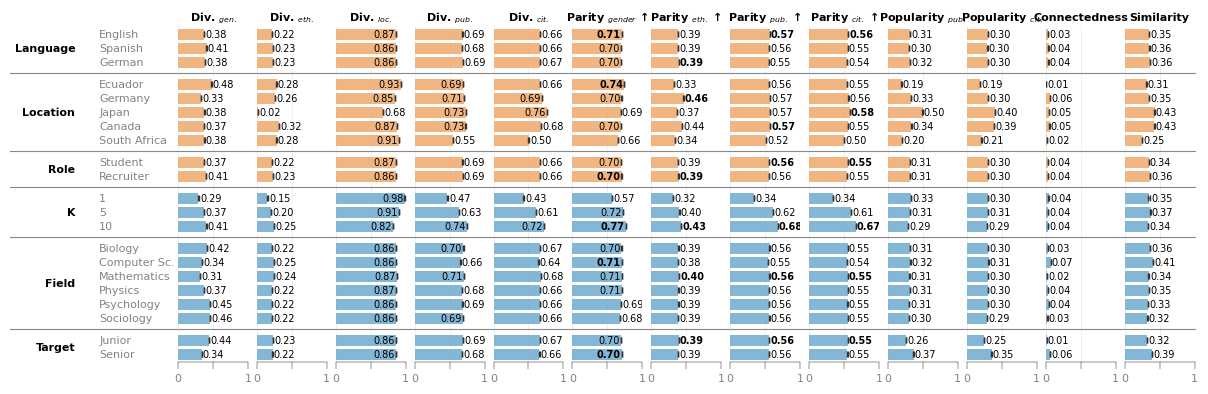

In [8]:
variables = {'persona': PERSONA_VARIABLES, 'context': MAIN_CONTEXT_VARIABLES}

df_metric = pd.DataFrame()
group_configs = []
for i, (prompt_var_class, vars) in enumerate(variables.items()):
    for j, var in enumerate(vars):
        tmp = aggregate_scores(df_valid_calls, [var]).rename(columns={var: 'label'})
        tmp.loc[:,'column'] = var
        df_metric = pd.concat([df_metric, tmp], ignore_index=True)

        group_configs.append({'label': var.split("_en")[0].capitalize(), 
                              'column': 'label', 
                              'color': PROMPT_VAR_COLORS.get(prompt_var_class), 
                              'filter': {'column':var},
                              'order': ORDER_MAP[var],
                              'shade': False})
            
for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_stacked.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_metric,
        group_configs=group_configs,
        row_labels = SENIORITY_MAP | ROLE_MAP | {'Computer Science':'Computer Sc.'},
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(group_configs)/1.1),
        textwrap_width = 20,
        section_style='plain',
        section_label_pad=0.2,
        section_label_align='right',
        row_label_align='left',
        section_label_width=0.5,
        row_label_width=1.9,
        row_label_pad=0.3,
        section_sep_left_pad=-0.22
    )


## RQ3: Insfrastructure

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_infrastructure_technical.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_infrastructure_technical.pdf


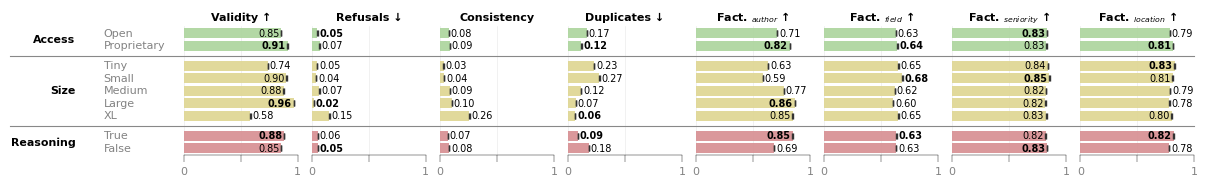

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_infrastructure_social.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_infrastructure_social.pdf


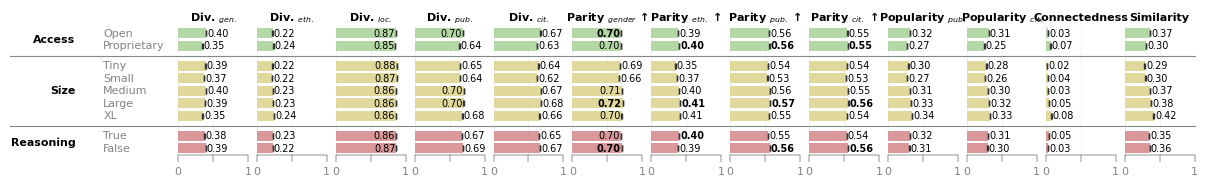

In [9]:

df_infra = pd.DataFrame()
for c in ['model_access','model_size','model_class']:
    tmp = aggregate_scores(df_valid_calls, [c]).rename(columns={c: 'label'})
    tmp.loc[:,'column'] = c
    df_infra = pd.concat([df_infra, tmp], ignore_index=True)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_infrastructure_{metric_type}.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_infra,
        group_configs=[
            {'label': MODEL_ARCHITECTURE_MAP['model_access'], 'column': 'label', 'filter': {'column': 'model_access'}, 'color': "#ADD59E", 'order': ACCESS_ORDER, 'shade': False},
            {'label': MODEL_ARCHITECTURE_MAP['model_size'],   'column': 'label', 'filter': {'column': 'model_size'},   'color': "#DFD693", 'order': SIZE_ORDER, 'shade': False},
            {'label': MODEL_ARCHITECTURE_MAP['model_class'],  'column': 'label', 'filter': {'column': 'model_class'},  'color': "#D78F93", 'order': REASONING_ORDER, 'shade': False},
        ],
        row_labels=ACCESS_MAP | SIZE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 2.1),
        textwrap_width = 20,
        section_style='plain',
        section_label_pad=0.2,
        section_label_align='right',
        row_label_align='left',
        section_label_width=0.5,
        row_label_width=1.9,
        row_label_pad=0.3,
        section_sep_left_pad=-0.22
    )


## RQ4: Socio-Technical Trade-off

Scatter — 43 models
Technical max: 6.272, Social max: 2.405


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_vs_social.pdf


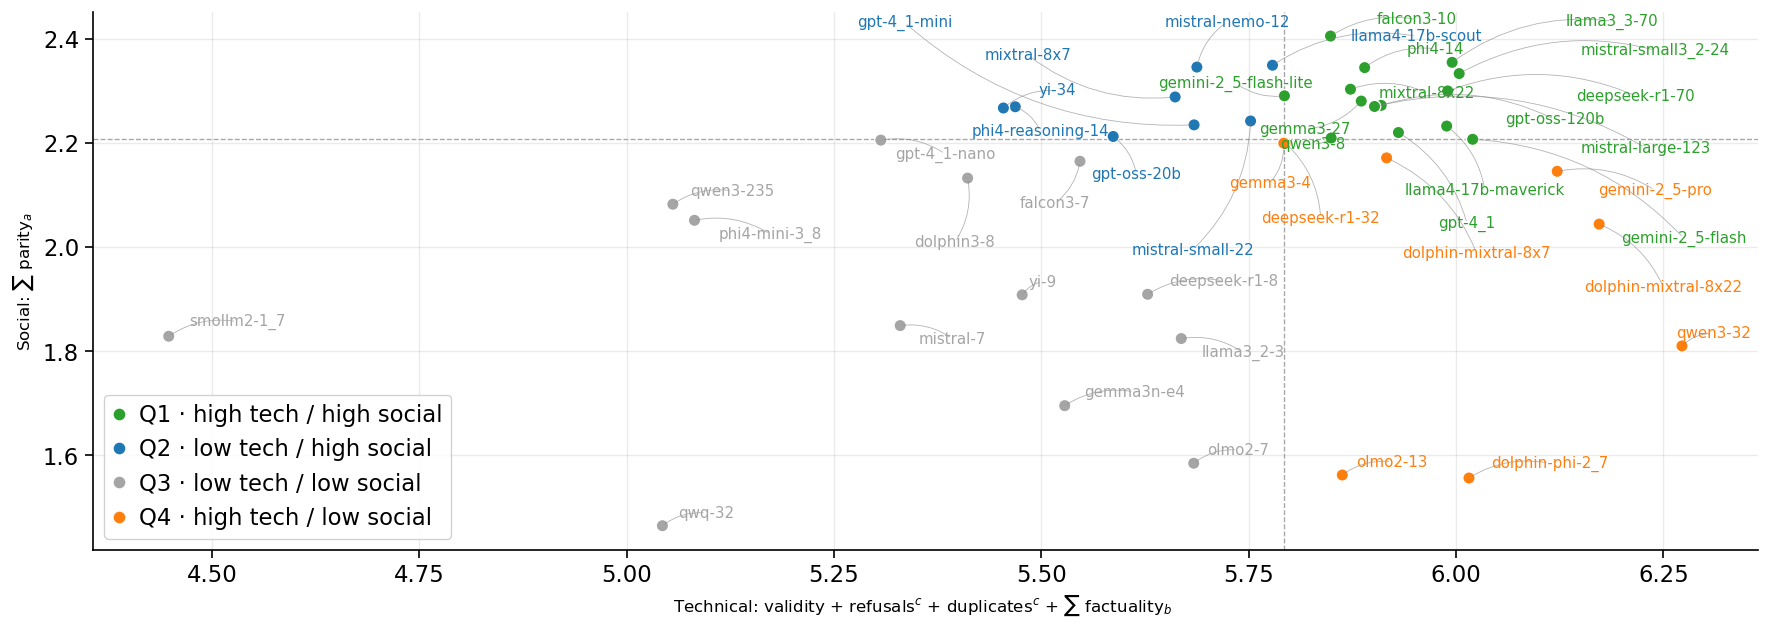

In [10]:

df_data_tmp = df_valid_calls.copy()

agg_cols = TECHNICAL_METRICS_NORM + PARITY_METRICS

df_data_tmp.loc[:, 'color'] = df_data_tmp.loc[:,'model_family'].apply(lambda fam: MODEL_FAMILY_COLORS.get(fam, '#6B7280'))

per_model_mean = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False, observed=True)[agg_cols]
                  .mean()
                  .reset_index())
per_model_std = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False, observed=True)[agg_cols]
                  .std()
                  .reset_index())

per_model_mean['x_technical'] = per_model_mean[TECHNICAL_METRICS_NORM].sum(axis=1, skipna=False)
per_model_mean['y_social']    = per_model_mean[PARITY_METRICS].sum(axis=1, skipna=False)

per_model_std['x_technical'] = per_model_std[TECHNICAL_METRICS_NORM].sum(axis=1, skipna=False)
per_model_std['y_social']    = per_model_std[PARITY_METRICS].sum(axis=1, skipna=False)

print(f'Scatter — {per_model_mean.model_short_name.nunique()} models')
print(f"Technical max: {per_model_mean['x_technical'].max():.3f}, Social max: {per_model_mean['y_social'].max():.3f}")

fig, ax = plot_quadrant_scatter(per_model_mean, label_col="model_short_name", figsize=(FIG_WIDTH, 5.5), show_quadrant_legend=True)

fn = str(PLOTS_DIR / f'plot_technical_vs_social.pdf')
plt.savefig(fn, bbox_inches='tight', dpi=FIG_DPI)
print(fn)

plt.show()
plt.close()


# Additional

___


## K

,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,1,309600,0.9096,0.0010,0.2868,0.0311,0.0006,0.1735,0.0420,0.0055,0.1918,0.3464,0.0173,0.6000,0.1150,0.0009,0.2202,0.0166,0.0003,0.0936,...,0.0023,0.4698,0.3317,0.0023,0.4672,0.3210,0.0023,0.4638,0.3775,0.0023,0.4810,0.3015,0.0022,0.4555,0.3317,0.0023,0.4672,0.3015,0.0022,0.4555
1,5,309600,0.8560,0.0012,0.3511,0.0567,0.0008,0.2313,0.0369,0.0006,0.1316,0.3711,0.0020,0.4301,0.0693,0.0005,0.1273,0.2154,0.0012,0.3170,...,0.0013,0.2856,0.3138,0.0013,0.3000,0.3623,0.0015,0.3452,0.3293,0.0013,0.2912,0.3084,0.0013,0.3040,0.3138,0.0013,0.3000,0.3084,0.0013,0.3040
2,10,309600,0.8199,0.0014,0.3843,0.0702,0.0009,0.2555,0.0394,0.0006,0.1194,0.3391,0.0015,0.3285,0.0531,0.0004,0.0986,0.2580,0.0014,0.3502,...,0.0011,0.2395,0.2910,0.0011,0.2557,0.3897,0.0014,0.3109,0.3191,0.0011,0.2434,0.2912,0.0012,0.2616,0.2910,0.0011,0.2557,0.2912,0.0012,0.2616


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_k.pdf


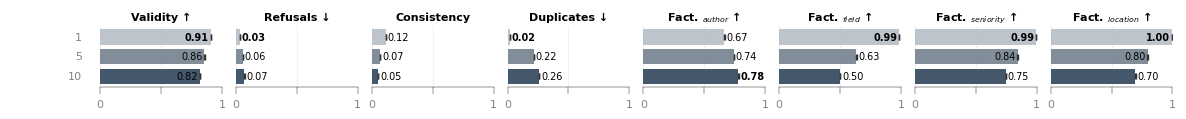

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_k.pdf


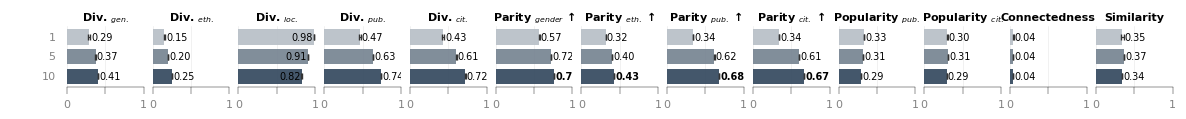

In [11]:
df_k = aggregate_scores(df_valid_calls, ['k'])
display(df_k)

for metric_type, metric_list in METRIC_TYPES.items():

    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k.pdf')
    print(fn)
    plot_grouped_metrics(
        df_k,
        group_configs=[
            {'label': 'Top-k', 'column': 'k', 'color': '#34495E', 'order': K_ORDER},
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )

### K and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_k_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_k_lang.pdf


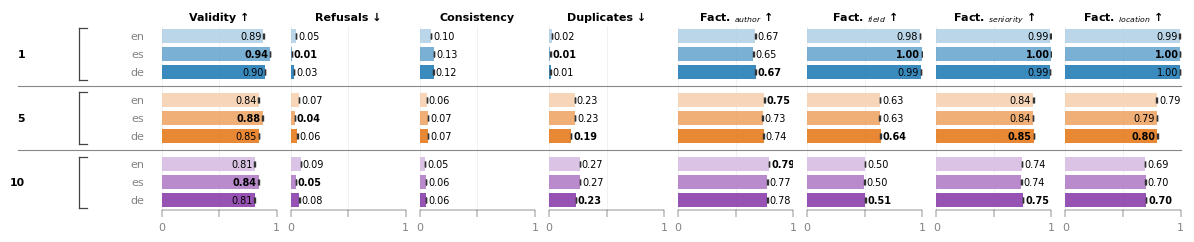

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_k_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_k_lang.pdf


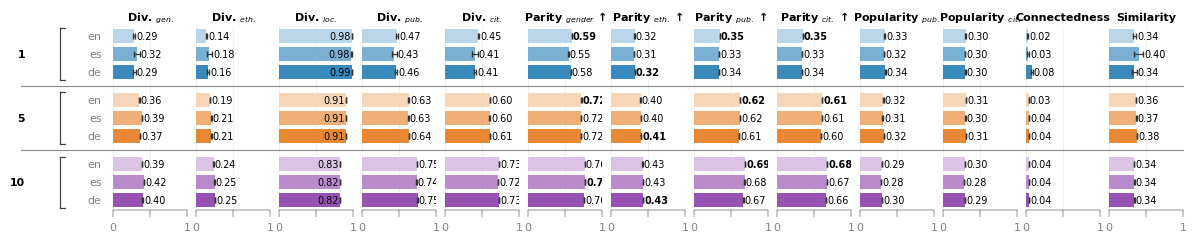

In [12]:

df_k_lang = aggregate_scores(df_valid_calls, ['k','language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k_lang.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_k_lang,
        group_configs=[
            {'label': str(k), 
             'column': 'language_en', 'color': K_COLORS[k], 'filter': {'k': k}, 'order': LANGUAGE_ORDER} for k in K_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


## Language

,language_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,English,309600,0.8454,0.0013,0.3615,0.0701,0.0009,0.2553,0.0348,0.0007,0.1178,0.3496,0.0022,0.3898,0.0687,0.0006,0.1437,0.1684,0.0011,0.2992,...,0.0015,0.3300,0.3132,0.0016,0.3405,0.3639,0.0017,0.3707,0.3316,0.0015,0.3354,0.3045,0.0016,0.3400,0.3132,0.0016,0.3405,0.3045,0.0016,0.3400
1,German,309600,0.8517,0.0013,0.3554,0.0557,0.0008,0.2293,0.0393,0.0008,0.1294,0.3599,0.0023,0.3859,0.0824,0.0006,0.1611,0.1425,0.0011,0.2818,...,0.0016,0.3439,0.3186,0.0016,0.3536,0.3502,0.0017,0.3764,0.3482,0.0016,0.3554,0.3015,0.0016,0.3485,0.3186,0.0016,0.3536,0.3015,0.0016,0.3485
2,Spanish,309600,0.8884,0.0011,0.3148,0.0322,0.0006,0.1765,0.0406,0.0007,0.1324,0.3553,0.0022,0.3826,0.0842,0.0006,0.1684,0.1658,0.0011,0.3003,...,0.0015,0.3381,0.3018,0.0015,0.3412,0.3653,0.0017,0.3755,0.3395,0.0015,0.3448,0.2952,0.0015,0.3408,0.3018,0.0015,0.3412,0.2952,0.0015,0.3408


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_lang.pdf


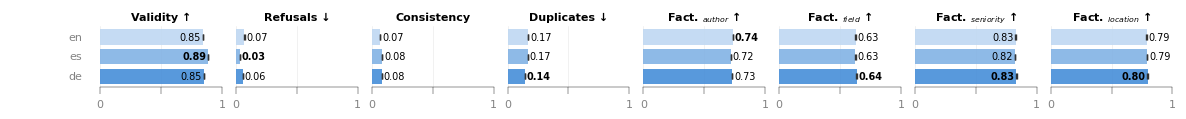

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_lang.pdf


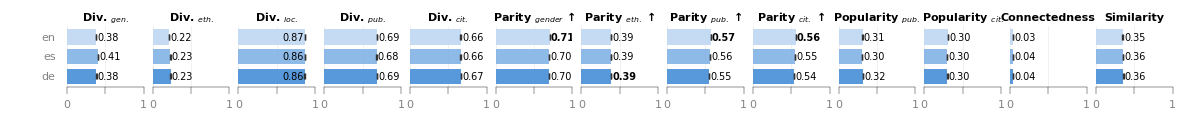

In [13]:

df_lang = aggregate_scores(df_valid_calls, ['language_en'])
display(df_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang,
        group_configs=[
            {'label': 'Language', 
             'column': 'language_en', 
             'color': '#4A90D9',
             'order': LANGUAGE_ORDER},
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )


### Language and K

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_lang_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_lang_k.pdf


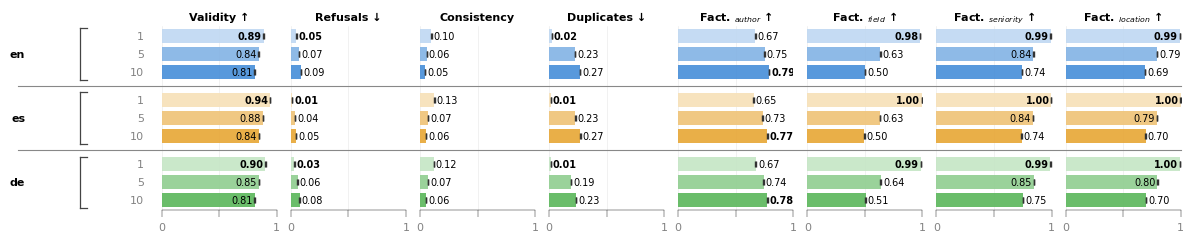

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_lang_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_lang_k.pdf


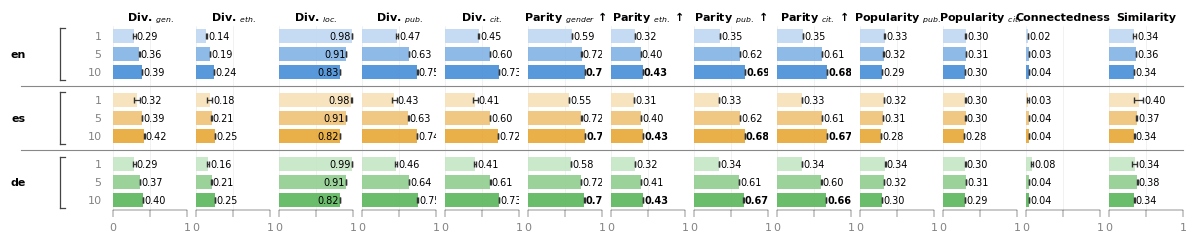

In [14]:
df_lang_k = aggregate_scores(df_valid_calls, ['language_en','k'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang_k.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_lang_k,
        group_configs=[
            {'label': LANGUAGE_MAP[lang], 
             'column': 'k', 
             'color': LANGUAGE_COLORS[lang],
             'filter': {'language_en': lang}, 
             'order': K_ORDER} for lang in LANGUAGE_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


### Language and Task

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task_lang.pdf


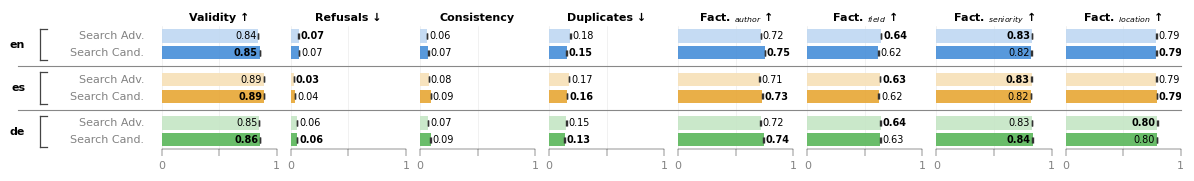

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_task_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_task_lang.pdf


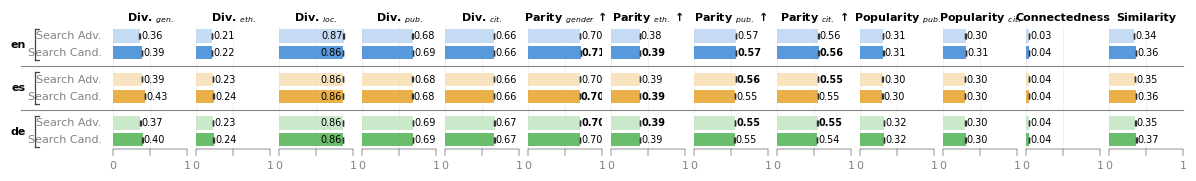

In [15]:

from pydoc import text


df_lang_task = aggregate_scores(df_valid_calls, ['language_en','task_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang_task,
        group_configs=[
            {'label': LANGUAGE_MAP[language], 
             'column': 'task_en', 
             'color': LANGUAGE_COLORS[language],
             'filter': {'language_en': language}, 
             'order': TASK_ORDER}
            for language in LANGUAGE_ORDER
        ],
        row_labels=TASK_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER)),
        textwrap_width=25
    )


## Location

,location_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Canada,185760,0.8634,0.0016,0.3435,0.0503,0.0010,0.2186,0.0546,0.0011,0.1554,0.4256,0.0028,0.3767,0.1075,0.0009,0.1845,0.1427,0.0014,0.2824,...,0.0020,0.3399,0.3365,0.0020,0.3440,0.2554,0.0019,0.3319,0.3538,0.0020,0.3490,0.3909,0.0021,0.3652,0.3365,0.0020,0.3440,0.3909,0.0021,0.3652
1,Ecuador,185760,0.8522,0.0016,0.3549,0.0608,0.0011,0.2390,0.0059,0.0004,0.0504,0.3144,0.0026,0.3688,0.0539,0.0006,0.1275,0.1061,0.0012,0.2415,...,0.0019,0.3464,0.1948,0.0016,0.2797,0.4174,0.0022,0.3879,0.3887,0.0020,0.3546,0.1938,0.0015,0.2786,0.1948,0.0016,0.2797,0.1938,0.0015,0.2786
2,Germany,185760,0.8638,0.0016,0.3431,0.0486,0.0010,0.2150,0.0590,0.0012,0.1588,0.3459,0.0028,0.3719,0.0847,0.0008,0.1643,0.1637,0.0015,0.2983,...,0.0020,0.3305,0.3277,0.0021,0.3456,0.3494,0.0021,0.3573,0.3472,0.0020,0.3431,0.3033,0.0020,0.3405,0.3277,0.0021,0.3456,0.3033,0.0020,0.3405
3,Japan,185760,0.8739,0.0015,0.3320,0.0496,0.0010,0.2172,0.0505,0.0010,0.1323,0.4281,0.0026,0.3417,0.0786,0.0008,0.1588,0.1377,0.0015,0.3015,...,0.0019,0.3155,0.4960,0.0021,0.3582,0.2750,0.0019,0.3174,0.3257,0.0019,0.3316,0.3993,0.0021,0.3528,0.4960,0.0021,0.3582,0.3993,0.0021,0.3528
4,South Africa,185760,0.8559,0.0016,0.3512,0.0539,0.0010,0.2259,0.0227,0.0008,0.0958,0.2499,0.0035,0.4448,0.0695,0.0007,0.1476,0.2451,0.0016,0.3218,...,0.0022,0.3434,0.1973,0.0019,0.3017,0.5217,0.0026,0.4129,0.2672,0.0021,0.3344,0.2111,0.0020,0.3179,0.1973,0.0019,0.3017,0.2111,0.0020,0.3179


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_loc.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_loc.pdf


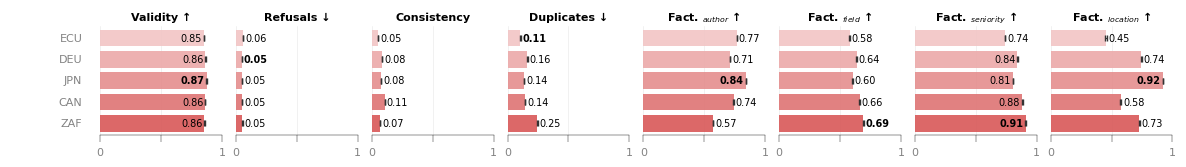

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_loc.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_loc.pdf


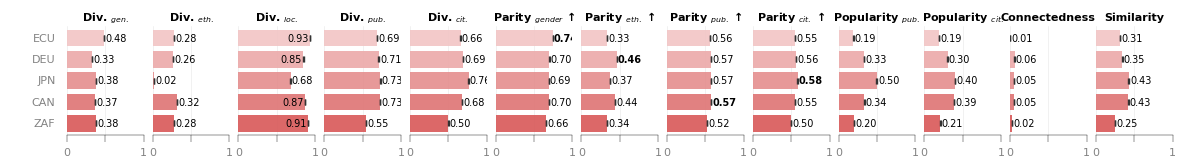

In [16]:

df_loc = aggregate_scores(df_valid_calls, ['location_en'])
display(df_loc)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc,
        group_configs=[
            {'label': 'Location', 
             'column': 'location_en', 
             'color': '#D95B5B',
             'order': LOCATION_ORDER},
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        row_labels=LOCATION_MAP,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(LOCATION_ORDER)/8))
    )


### Location and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_loc_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_loc_lang.pdf


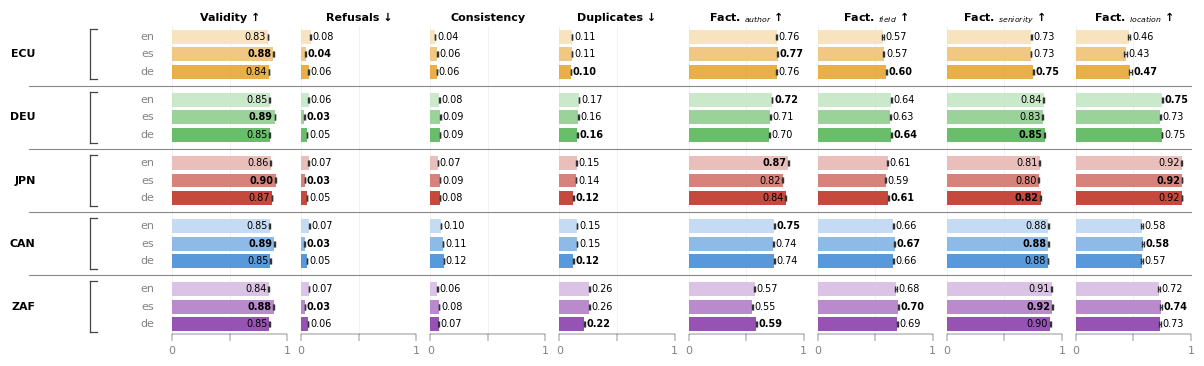

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_loc_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_loc_lang.pdf


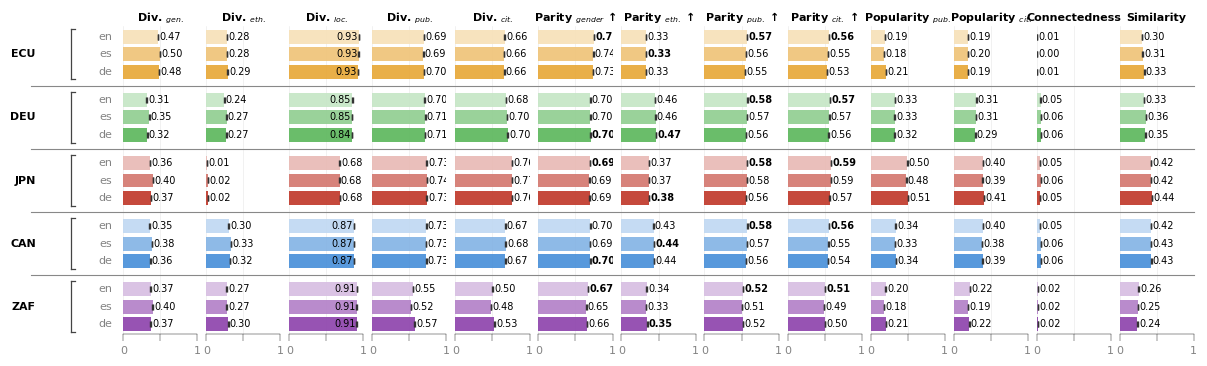

In [17]:

df_loc_lang = aggregate_scores(df_valid_calls, ['location_en','language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc_lang,
        group_configs=[
            {'label': LOCATION_MAP[loc], 
             'column': 
             'language_en', 
             'color': LOCATION_COLORS[loc],
             'filter': {'location_en': loc}, 
             'order': LANGUAGE_ORDER} for loc in LOCATION_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LOCATION_ORDER))   
    );


## Task

,task_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,seeking an advisor,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0387,0.0006,0.1268,0.3444,0.0019,0.3897,0.0705,0.0005,0.1502,0.1701,0.0009,0.3014,...,0.0013,0.3356,0.3110,0.0013,0.3446,0.3674,0.0014,0.3740,0.3332,0.0013,0.3417,0.2994,0.0013,0.3422,0.3110,0.0013,0.3446,0.2994,0.0013,0.3422
1,seeking potential hires,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0378,0.0006,0.1266,0.3647,0.0018,0.3825,0.0863,0.0005,0.1655,0.1480,0.0009,0.2865,...,0.0012,0.3391,0.3110,0.0013,0.3457,0.3528,0.0014,0.3744,0.3460,0.0013,0.3488,0.3012,0.0013,0.3440,0.3110,0.0013,0.3457,0.3012,0.0013,0.3440


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task.pdf


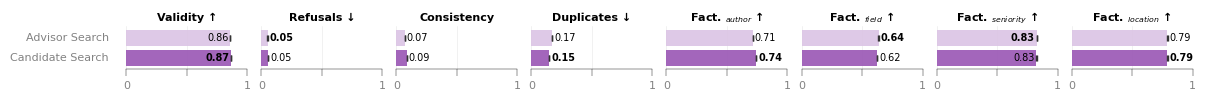

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_task.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_task.pdf


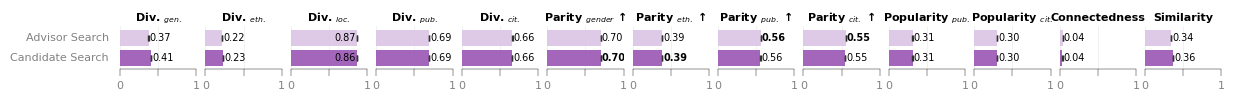

In [18]:
df_task = aggregate_scores(df_valid_calls, ['task_en'])
display(df_task)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task,
        group_configs=[
            {'label': 'Task', 
             'column': 'task_en', 
             'color': '#9B59B6',
             'order': TASK_ORDER},
        ],
        row_labels=TASK_MAP_LONG,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7),
        textwrap_width=20
    )


### Task and K

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_task_k.pdf


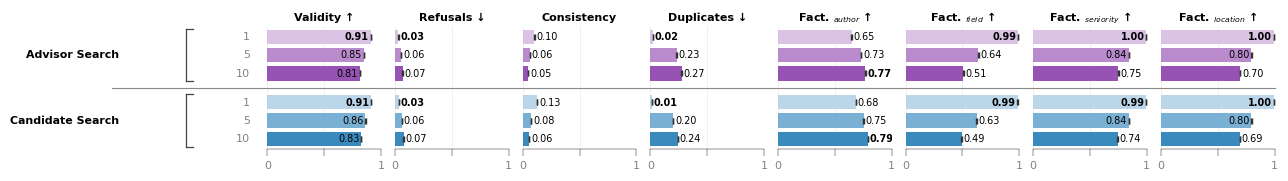

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_task_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_task_k.pdf


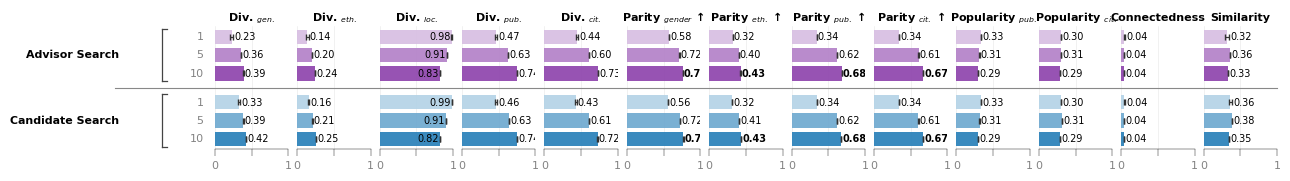

In [19]:

df_task_k = aggregate_scores(df_valid_calls, ['task_en','k'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task_k,
        group_configs=[
            {'label': TASK_MAP_LONG[task_val], 
             'column': 'k', 
             'color': TASK_COLORS[task_val],
             'filter': {'task_en': task_val}, 
             'order': K_ORDER} for task_val in TASK_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER)),
        textwrap_width=20
    )


## Role

,role_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Director/Recruiter,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0378,0.0006,0.1266,0.3647,0.0018,0.3825,0.0863,0.0005,0.1655,0.1480,0.0009,0.2865,...,0.0012,0.3391,0.3110,0.0013,0.3457,0.3528,0.0014,0.3744,0.3460,0.0013,0.3488,0.3012,0.0013,0.3440,0.3110,0.0013,0.3457,0.3012,0.0013,0.3440
1,PhD student,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0387,0.0006,0.1268,0.3444,0.0019,0.3897,0.0705,0.0005,0.1502,0.1701,0.0009,0.3014,...,0.0013,0.3356,0.3110,0.0013,0.3446,0.3674,0.0014,0.3740,0.3332,0.0013,0.3417,0.2994,0.0013,0.3422,0.3110,0.0013,0.3446,0.2994,0.0013,0.3422


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_role.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_role.pdf


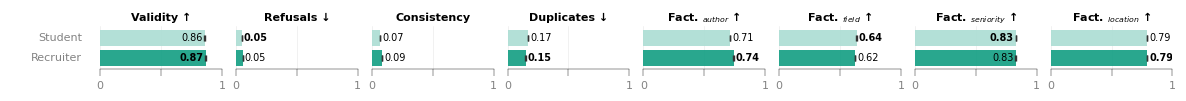

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_role.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_role.pdf


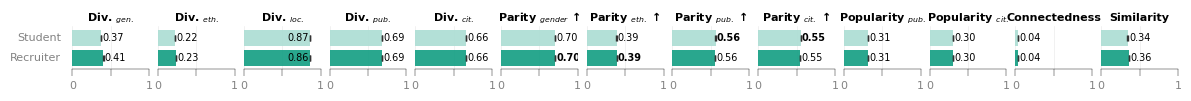

In [20]:

df_role = aggregate_scores(df_valid_calls, ['role_en'])
display(df_role)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_role,
        group_configs=[
            {'label': 'Role', 
             'column': 'role_en', 
             'color': '#16A085',
             'order': ROLE_ORDER},
        ],
        row_labels=ROLE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Role and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_role_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_role_lang.pdf


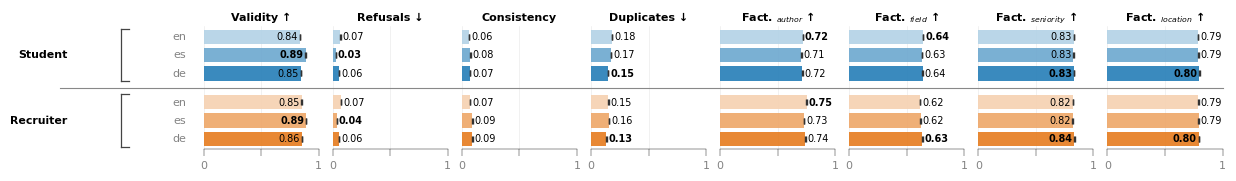

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_role_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_role_lang.pdf


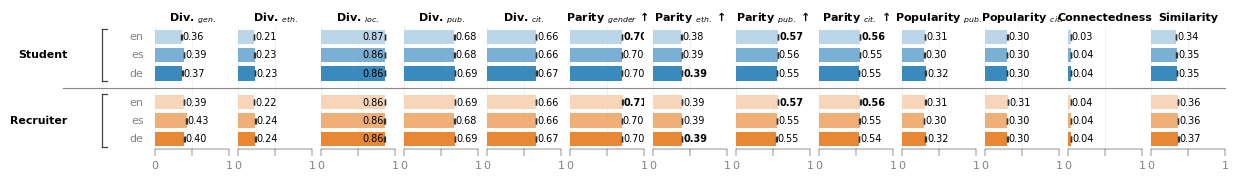

In [21]:

df_role_lang = aggregate_scores(df_valid_calls, ['role_en', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role_lang.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_role_lang,
        group_configs=[
            {'label': ROLE_MAP[role_val], 
             'column': 'language_en', 
             'color': ROLE_COLORS[role_val],
             'filter': {'role_en': role_val}, 
             'order': LANGUAGE_ORDER}
            for role_val in ROLE_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(ROLE_ORDER))
    )

## Field

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field.pdf


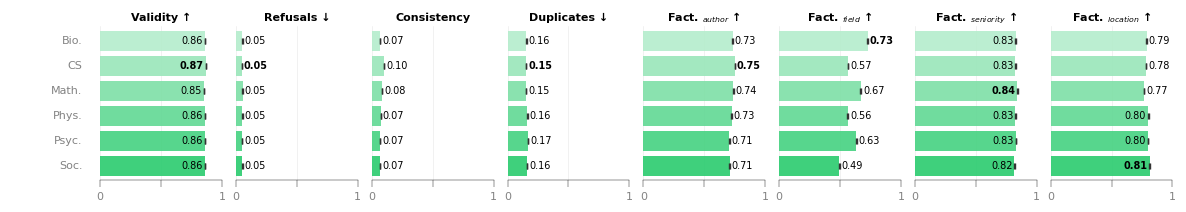

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_field.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_field.pdf


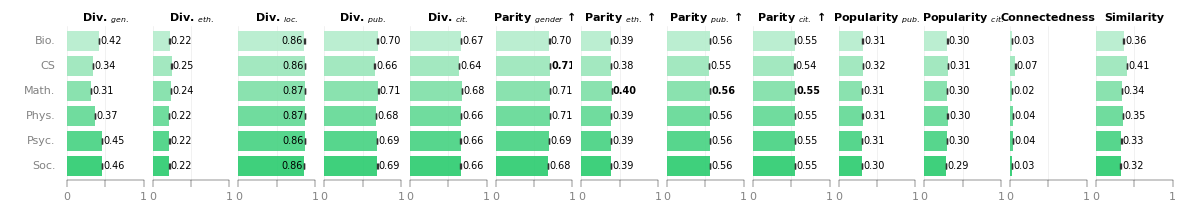

In [22]:

df_field = aggregate_scores(df_valid_calls, ['field_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field,
        group_configs=[
            {'label': 'Field', 
             'column': 'field_en', 
             'color': '#2ECC71', 
             'order': FIELD_ORDER},
        ],
        row_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(FIELD_ORDER)/5))
    )


### Field and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field_lang.pdf


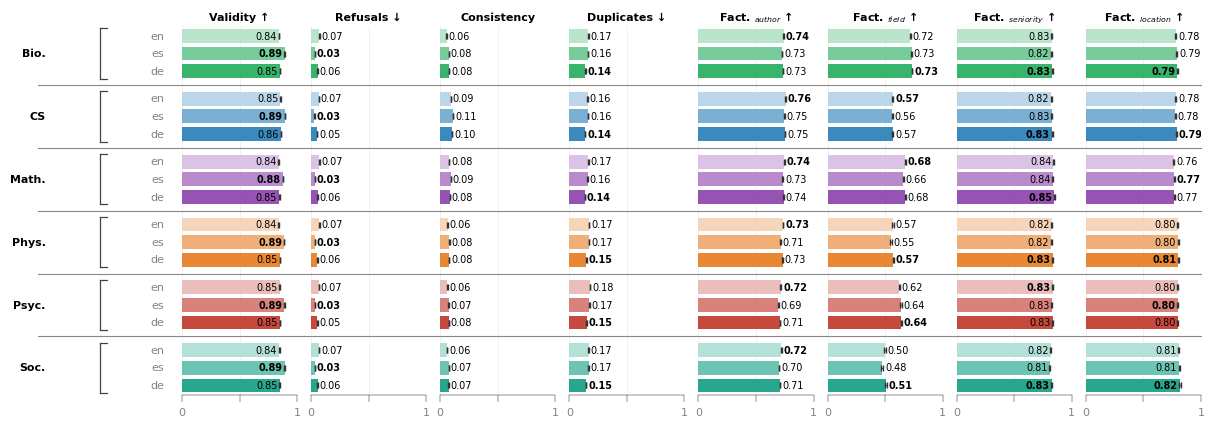

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_field_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_field_lang.pdf


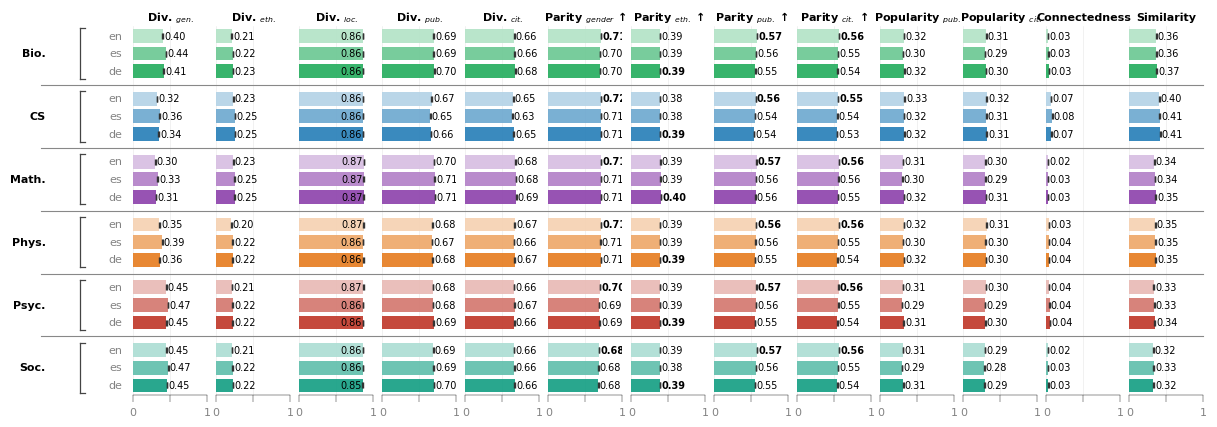

In [23]:

df_field_lang = aggregate_scores(df_valid_calls, ['field_en', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_lang,
        group_configs=[
            {'label': FIELD_MAP[field_en], 
             'column': 'language_en', 
             'color': FIELD_COLORS[field_en], 
             'filter': {'field_en': field_en}, 
             'order': LANGUAGE_ORDER } for field_en in FIELD_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER))
    )


### Field and K

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_field_k.pdf


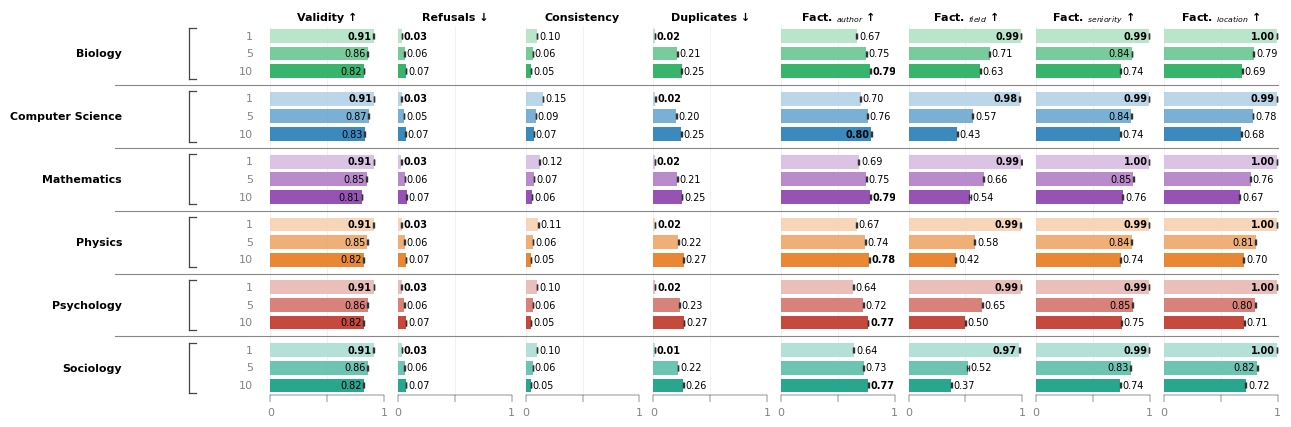

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_field_k.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_field_k.pdf


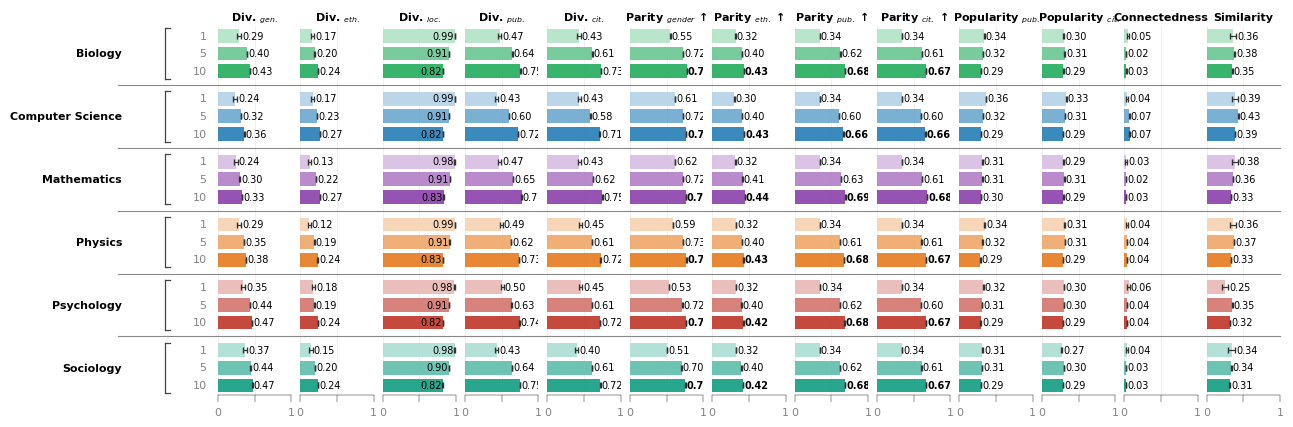

In [24]:

df_field_k = aggregate_scores(df_valid_calls, ['field_en', 'k'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_k,
        group_configs=[
            {'label': field_en, 
             'column': 'k', 
             'color': FIELD_COLORS[field_en], 
             'filter': {'field_en': field_en}, 
             'order': K_ORDER } for field_en in FIELD_ORDER
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER)),
        textwrap_width=20
    )


## Subfield

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_subfield.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_subfield.pdf


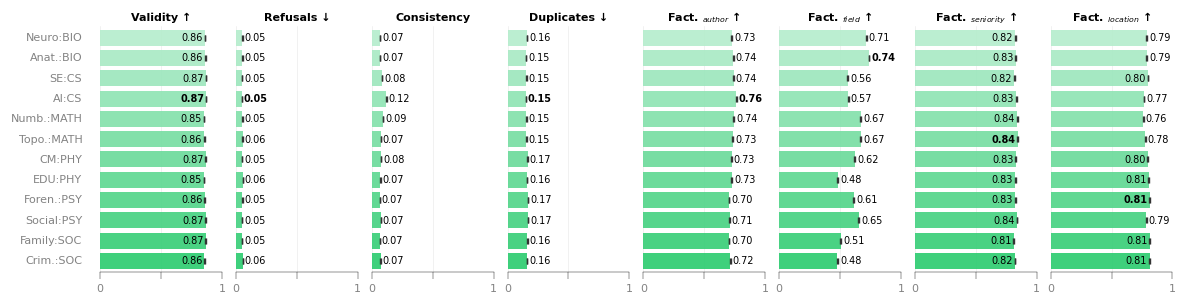

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_subfield.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_subfield.pdf


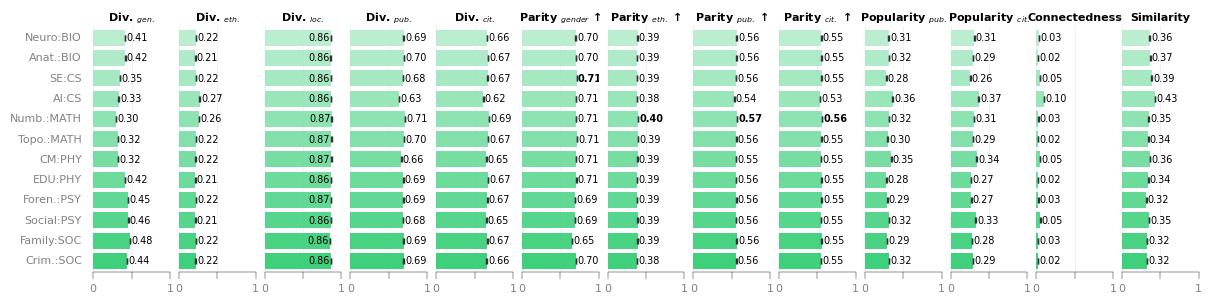

In [25]:

df_subfield = aggregate_scores(df_valid_calls, ['subfield_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_subfield.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_subfield,
        group_configs=[
            {'label': 'Subfield', 
             'column': 'subfield_en', 
             'color': '#2ECC71', 
             'order': SUBFIELD_ORDER},
        ],
        row_labels=SUBFIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(SUBFIELD_ORDER)/5))
    )


### Subfield and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_subfield_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_subfield_lang.pdf


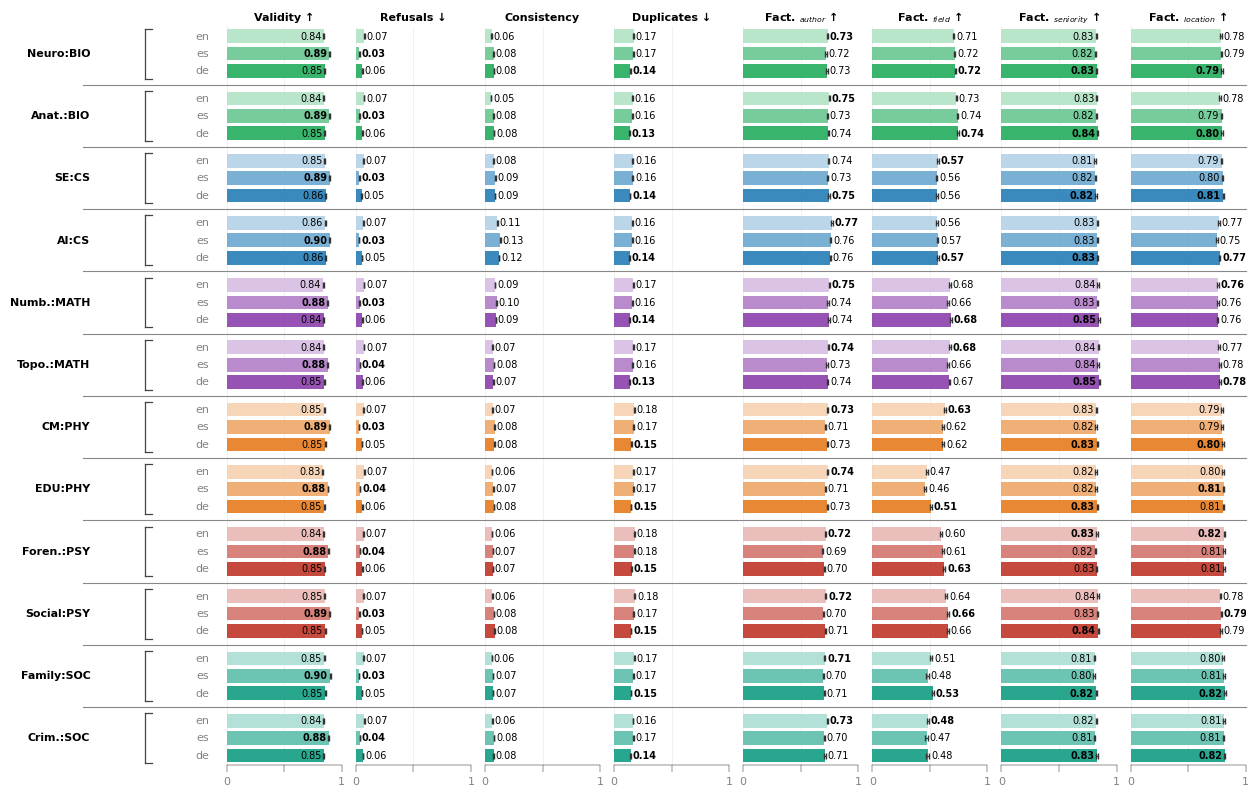

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_subfield_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_subfield_lang.pdf


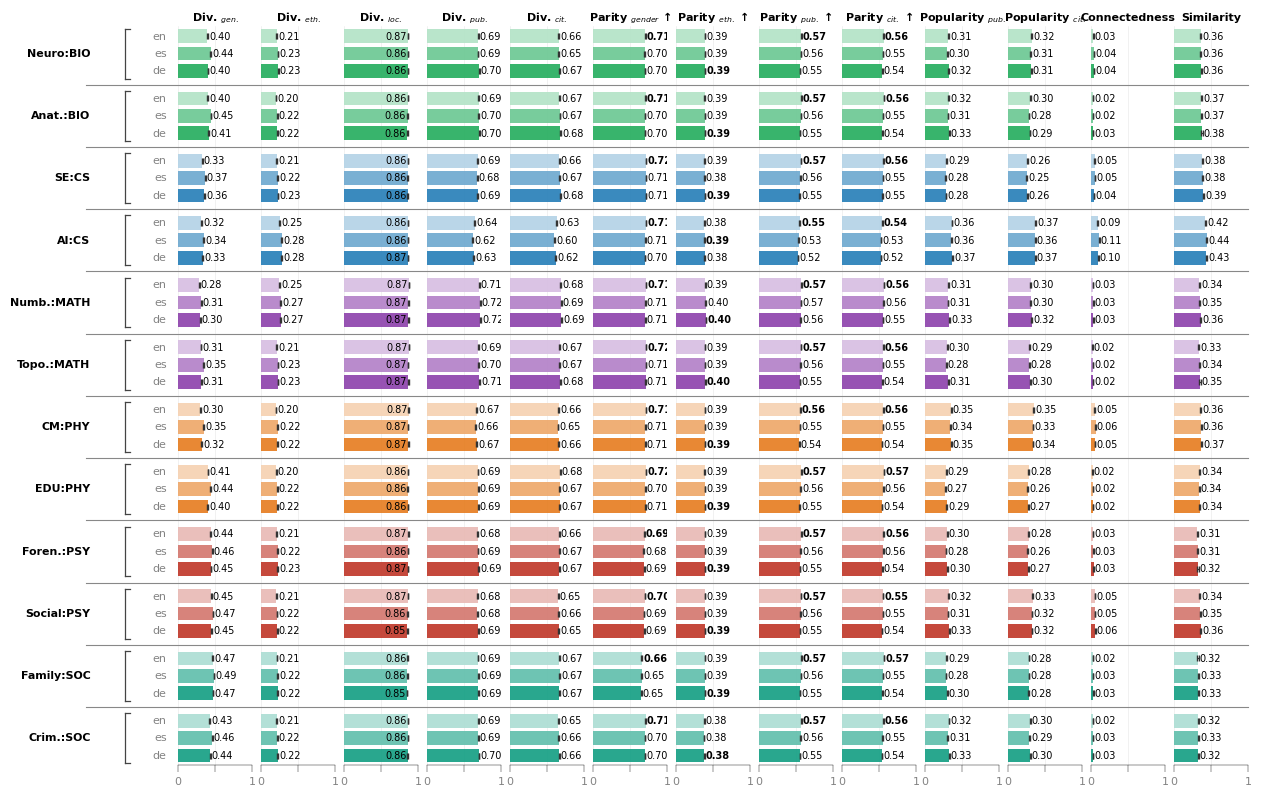

In [26]:

df_subfield_lang = aggregate_scores(df_valid_calls, ['subfield_en', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_subfield_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_subfield_lang,
        group_configs=[
            {'label': SUBFIELD_MAP[subfield_en], 
             'column': 'language_en', 
             'color': SUBFIELD_COLORS[subfield_en], 
             'filter': {'subfield_en': subfield_en}, 
             'order': LANGUAGE_ORDER } for subfield_en in SUBFIELD_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(SUBFIELD_ORDER))
    )


## Target (seniority)

,target_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,connectedness_mean,connectedness_ci,connectedness_std,similarity_mean,similarity_ci,similarity_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,...,pct_works_med_ci,pct_works_med_std,pct_works_high_mean,pct_works_high_ci,pct_works_high_std,pct_citations_low_mean,pct_citations_low_ci,pct_citations_low_std,pct_citations_med_mean,pct_citations_med_ci,pct_citations_med_std,pct_citations_high_mean,pct_citations_high_ci,pct_citations_high_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Junior Professor,464400,0.8565,0.0010,0.3506,0.0575,0.0007,0.2328,0.0146,0.0003,0.0704,0.3212,0.0017,0.3719,0.0649,0.0004,0.1390,0.1474,0.0009,0.2843,...,0.0012,0.3386,0.2597,0.0012,0.3202,0.3936,0.0014,0.3823,0.3565,0.0013,0.3509,0.2499,0.0011,0.3139,0.2597,0.0012,0.3202,0.2499,0.0011,0.3139
1,Senior Professor,464400,0.8672,0.0010,0.3394,0.0478,0.0006,0.2133,0.0632,0.0008,0.1629,0.3903,0.0019,0.3976,0.0926,0.0006,0.1750,0.1705,0.0009,0.3032,...,0.0013,0.3361,0.3659,0.0014,0.3621,0.3238,0.0014,0.3621,0.3220,0.0013,0.3385,0.3542,0.0014,0.3641,0.3659,0.0014,0.3621,0.3542,0.0014,0.3641


technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_seniority.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_seniority.pdf


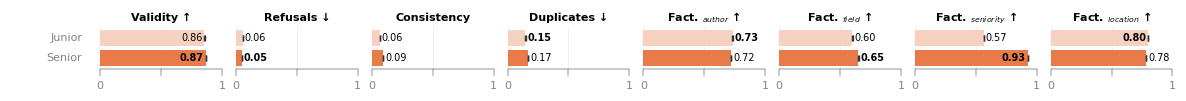

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_seniority.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_seniority.pdf


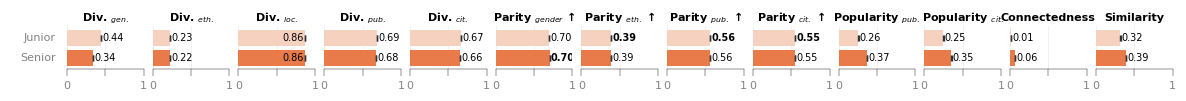

In [27]:

df_target = aggregate_scores(df_valid_calls, ['target_en'])
display(df_target)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_target,
        group_configs=[
            {'label': 'Target', 
             'column': 'target_en', 
             'color': '#E8703A',
             'order': SENIORITY_ORDER},
        ],
        row_labels=SENIORITY_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Seniority and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_seniority_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_seniority_lang.pdf


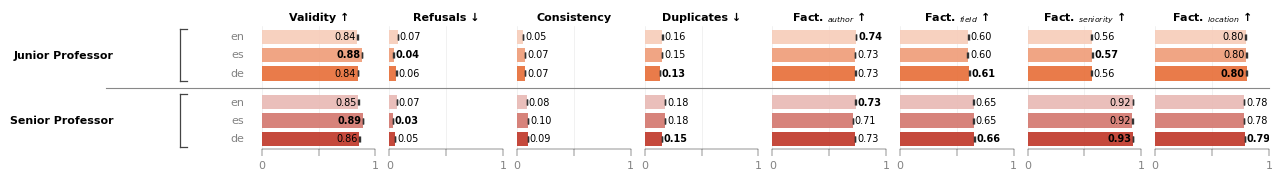

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_seniority_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_seniority_lang.pdf


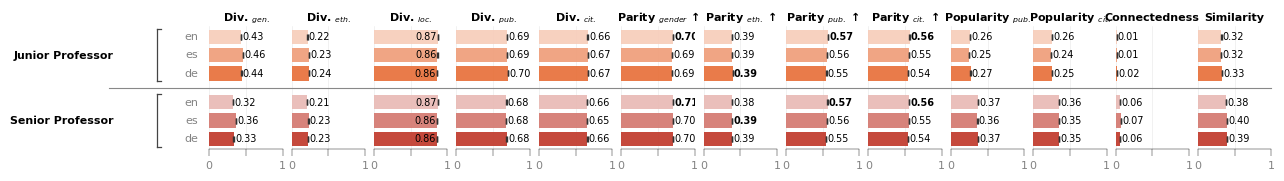

In [28]:

df_target_lang = aggregate_scores(df_valid_calls, ['target_en', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_target_lang,
        group_configs=[
            {'label': target_en, 
             'column': 'language_en', 
             'color': SENIORITY_COLORS[target_en],
            'filter': {'target_en': target_en}, 
            'order': LANGUAGE_ORDER}
            for target_en in SENIORITY_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(SENIORITY_ORDER)),
        textwrap_width=20
    )

## Model

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_model.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_model.pdf


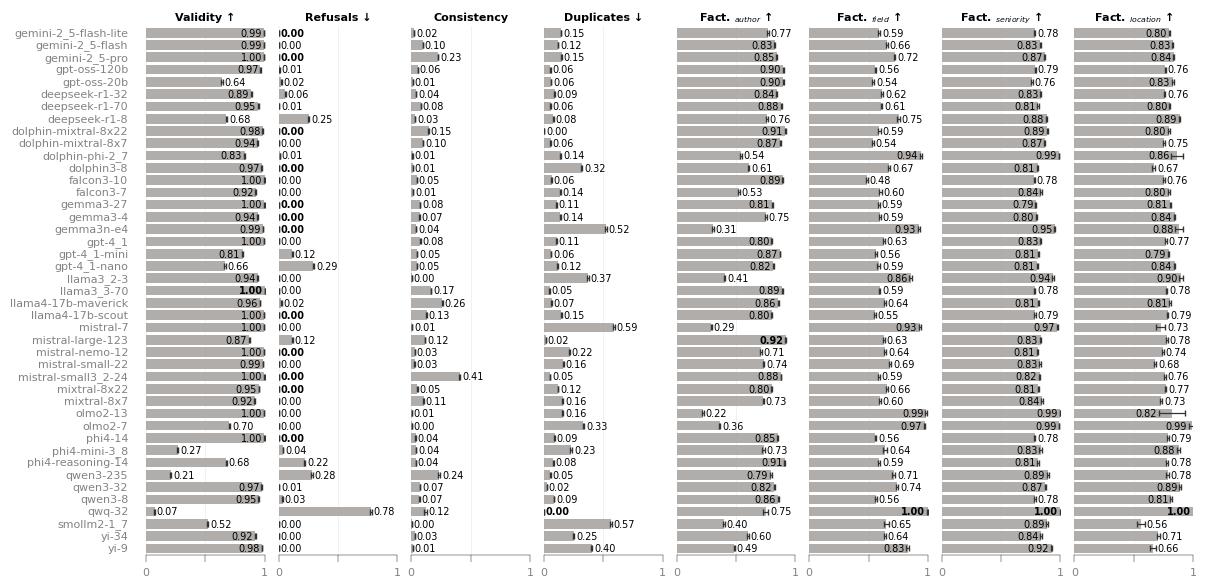

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_model.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_model.pdf


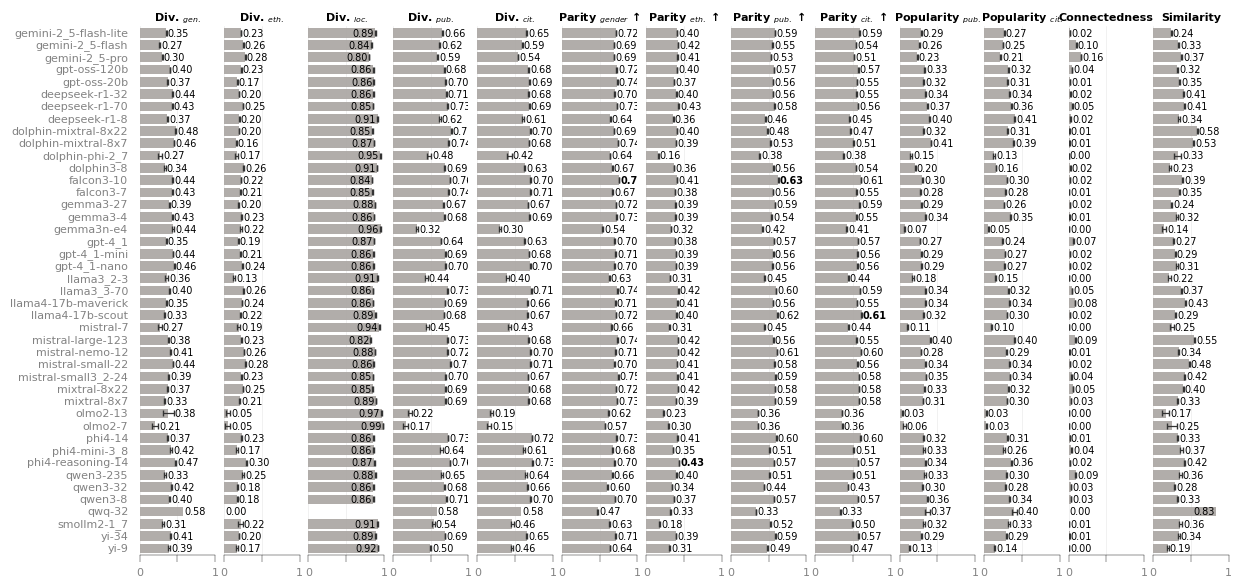

In [29]:

df_model = aggregate_scores(df_valid_calls, ['model_short_name'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_model.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_model,
        group_configs=[
            {'label': 'Model', 
             'column': 'model_short_name', 
             'color': "#ABA6A3",'order': MODELS,
             'shade': False}
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * (len(MODELS)/5)),
        textwrap_width = 25,
    )

### Model and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_model_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_model_lang.pdf


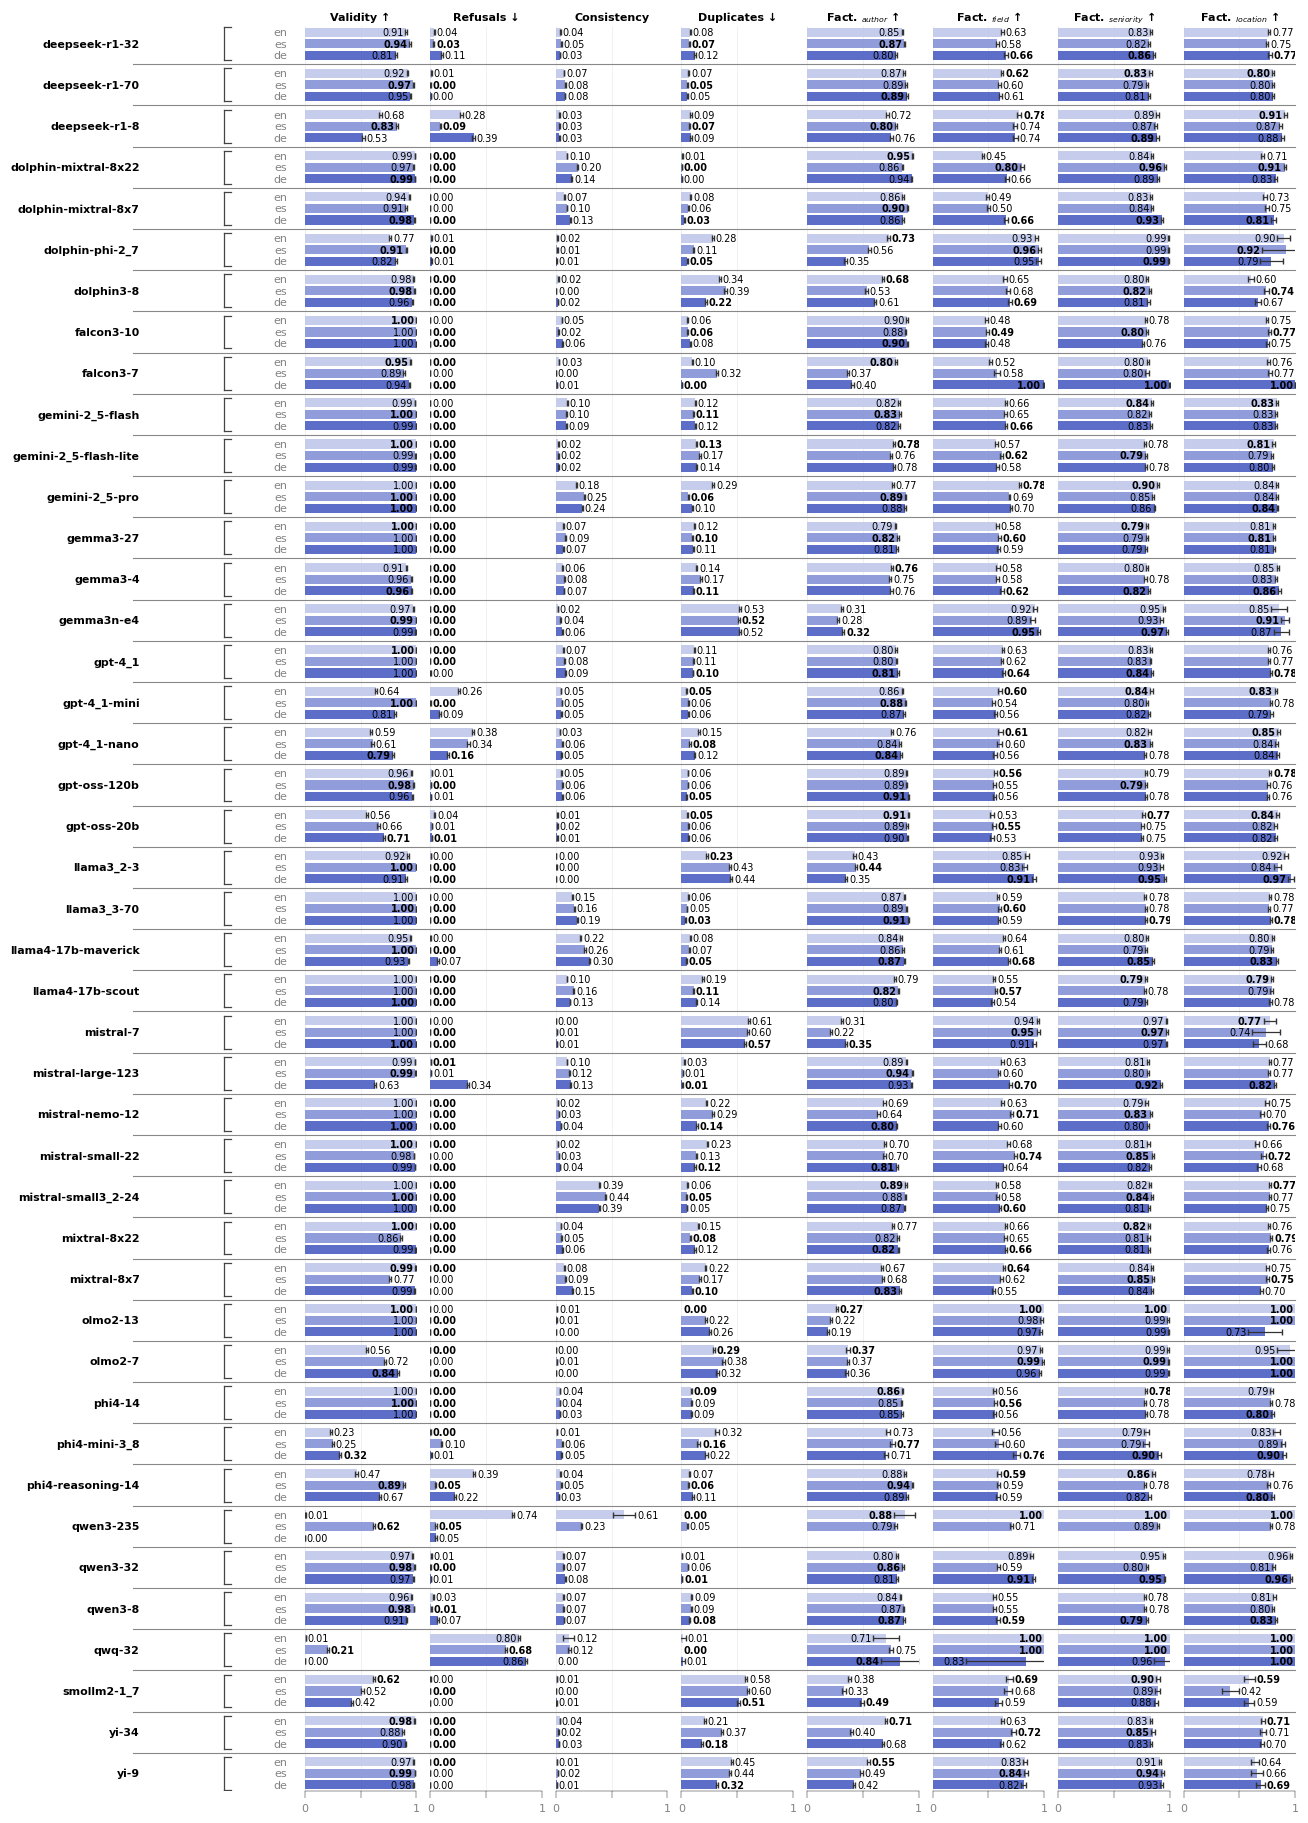

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_model_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_model_lang.pdf


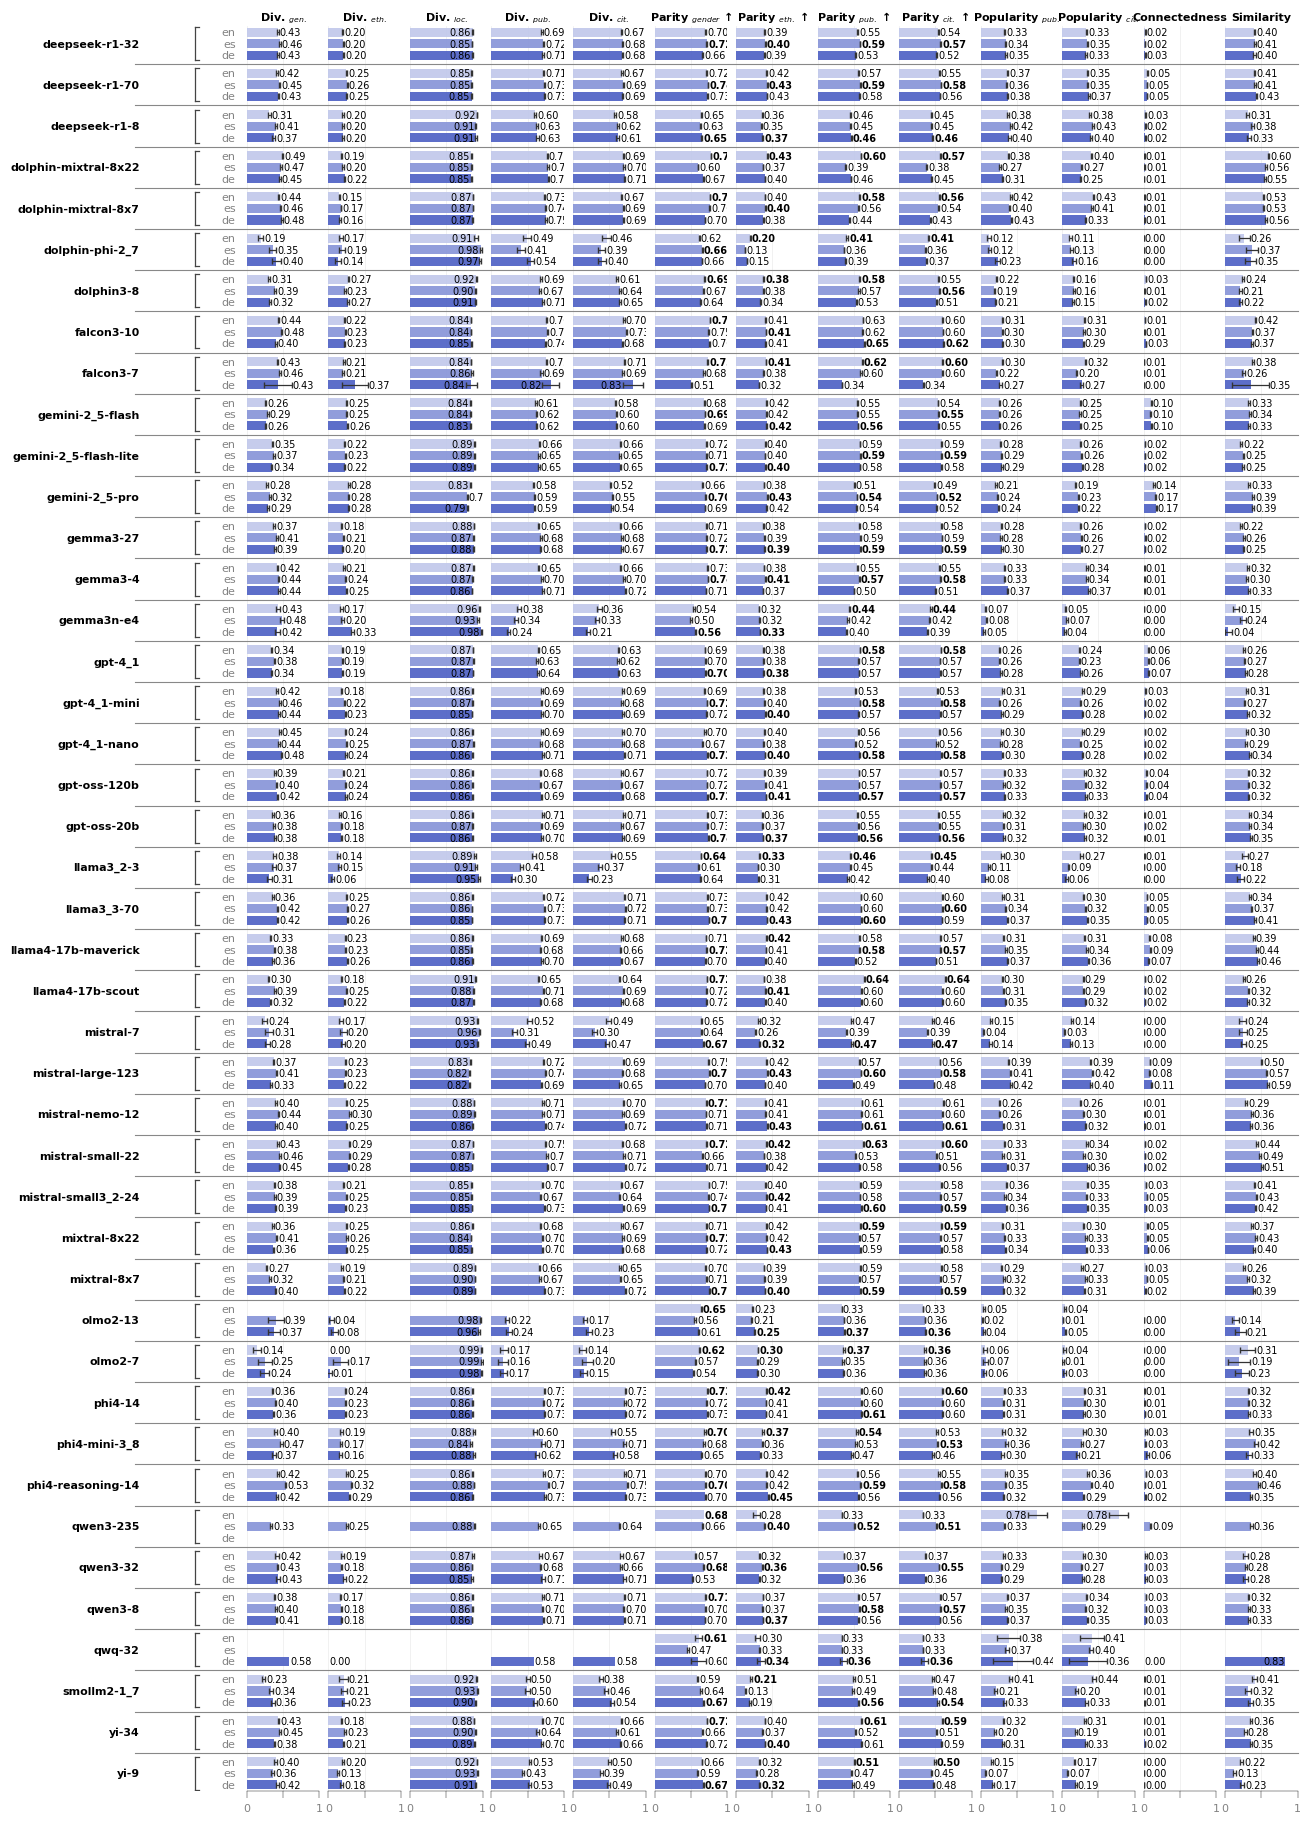

In [30]:
df_model_lang = aggregate_scores(df_valid_calls, ['model_short_name', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_model_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_model_lang,
        group_configs=[
            {'label': model, 
             'column': 'language_en', 
             'color': "#4F62C5",
            'filter': {'model_short_name': model}, 
            'order': LANGUAGE_ORDER}
            for model in df_model_lang.model_short_name.unique()
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(MODELS)/1.5),
        textwrap_width = 30
    )

## Model Family

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily.pdf


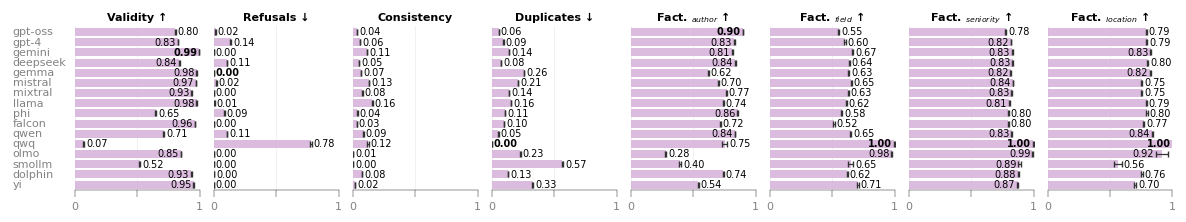

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily.pdf


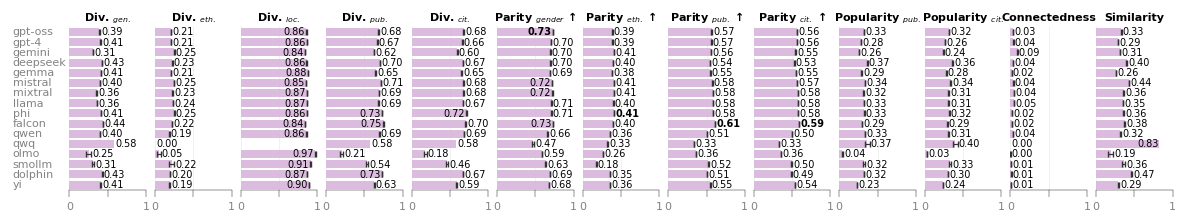

In [31]:
df_model_family = aggregate_scores(df_valid_calls, ['model_family'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_model_family,
        group_configs=[
            {'label': 'Model', 
             'column': 'model_family', 
             'color': "#D8B6DC",
             'order': MODEL_FAMILY_ORDER,
              'shade': False
             },
        ],
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * (len(df_model_family.model_family.unique())/6)),
        textwrap_width = 10,
        row_label_align='left',
        row_label_width=0.7,
        row_label_pad=0.22,
    )

### Model family and Language

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_lang.pdf


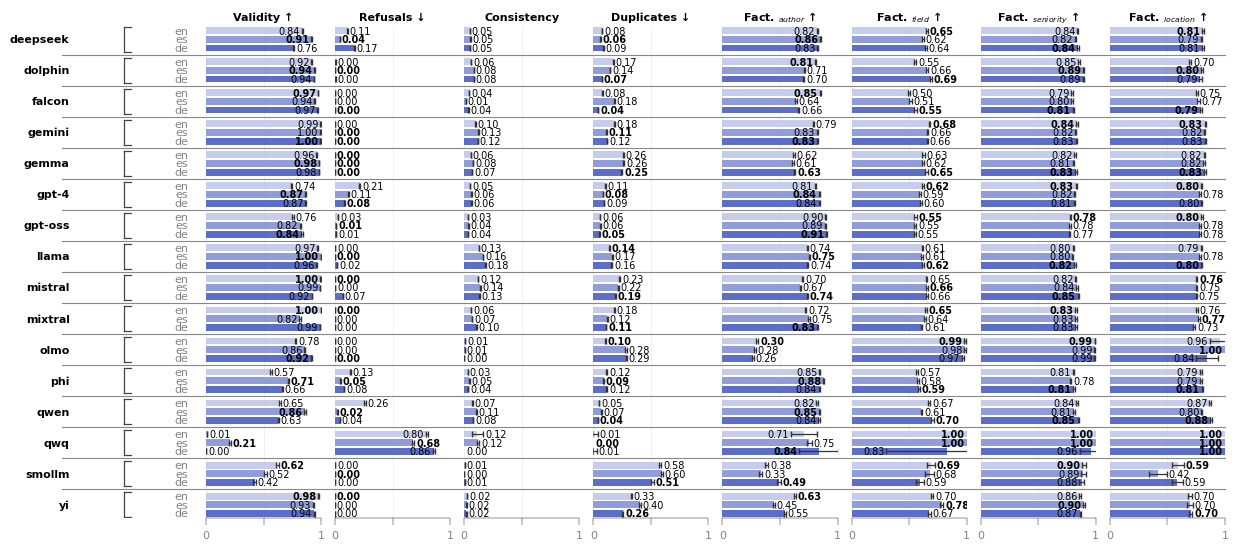

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_lang.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_lang.pdf


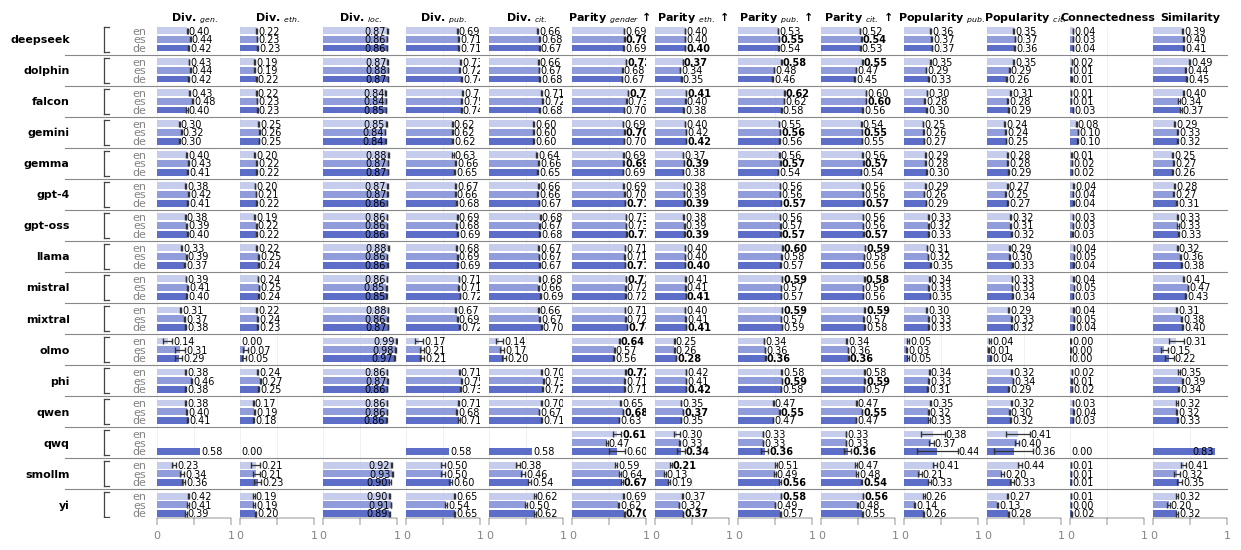

In [32]:
df_modelfamily_lang = aggregate_scores(df_valid_calls, ['model_family', 'language_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang,
        group_configs=[
            {'label': model_family, 
             'column': 'language_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': LANGUAGE_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()/2),
        textwrap_width = 12
    )

### Model familty and Country

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_loc.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_loc.pdf


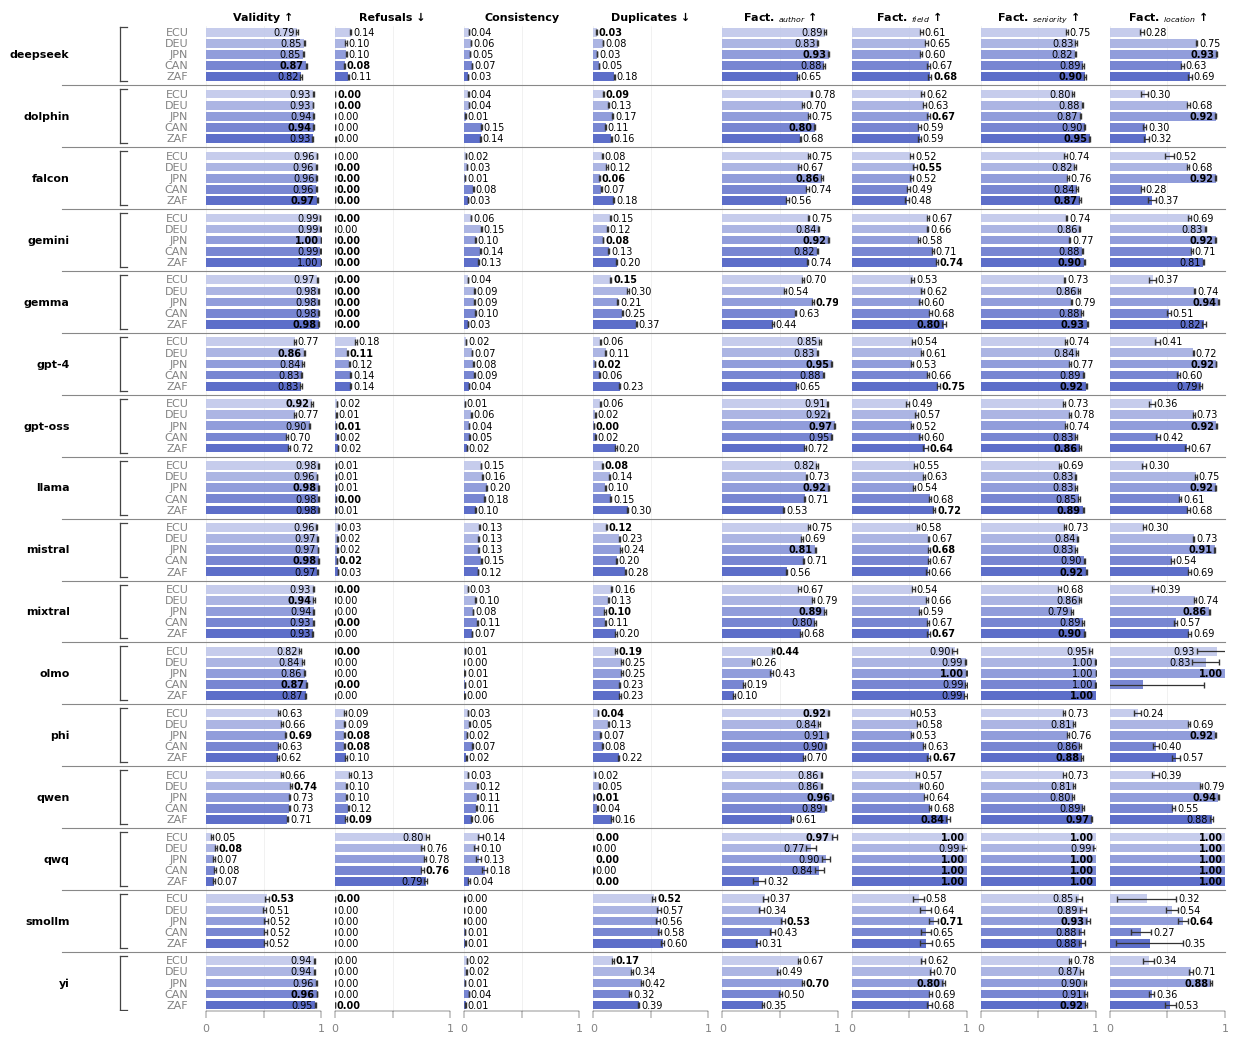

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_loc.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_loc.pdf


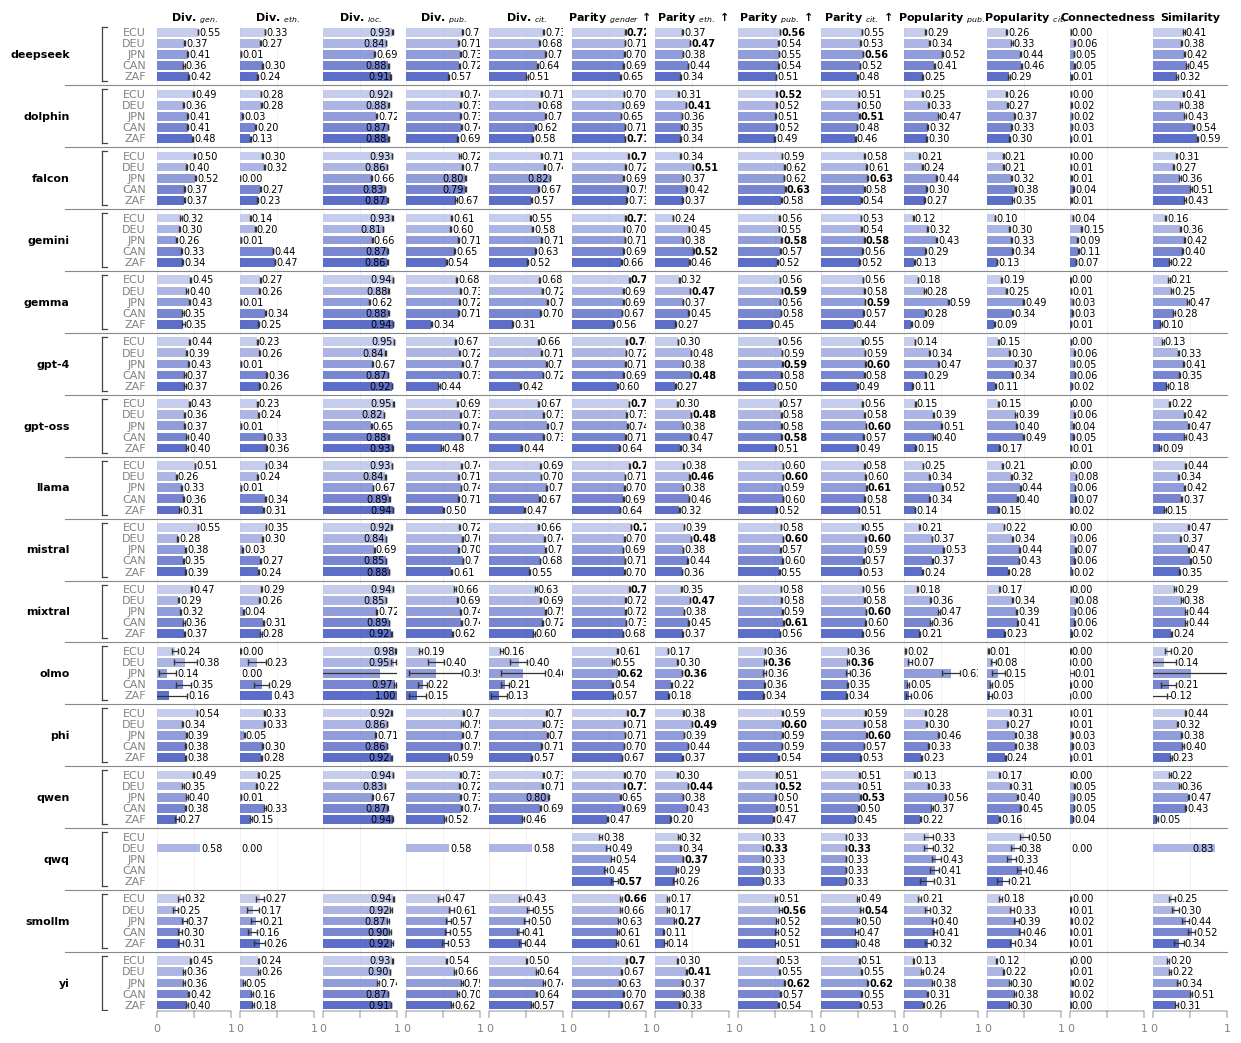

In [33]:
df_modelfamily_lang_loc = aggregate_scores(df_valid_calls, ['model_family', 'location_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_loc.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_loc,
        group_configs=[
            {'label': model_family, 
             'column': 'location_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': LOCATION_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=LOCATION_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()),
        textwrap_width = 12
    )

### Model family and Seniority

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_target.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_target.pdf


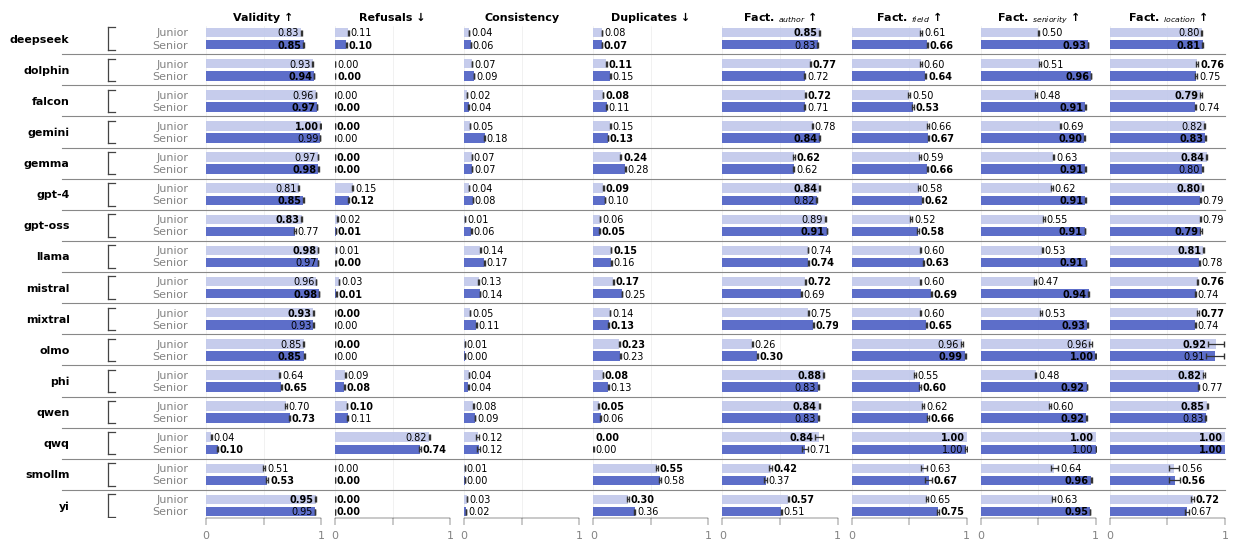

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_target.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_target.pdf


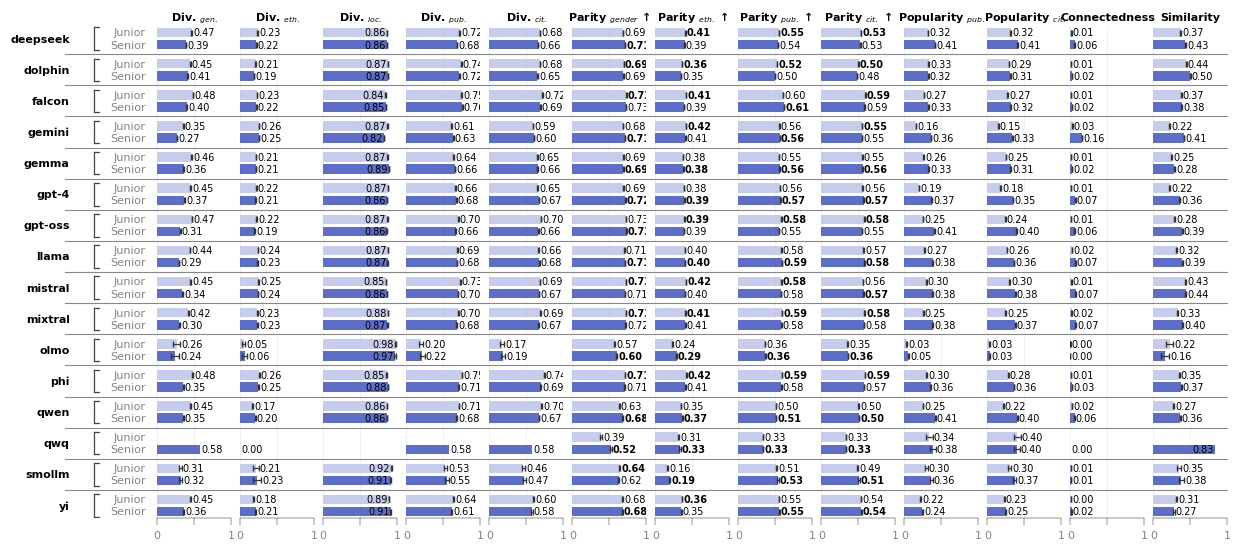

In [34]:
df_modelfamily_lang_target = aggregate_scores(df_valid_calls, ['model_family', 'target_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_target.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_target,
        group_configs=[
            {'label': model_family, 
             'column': 'target_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': SENIORITY_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=SENIORITY_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()/2),
        textwrap_width = 12
    )

### Model familty and Field

technical
/code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_field.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_technical_modelfamily_field.pdf


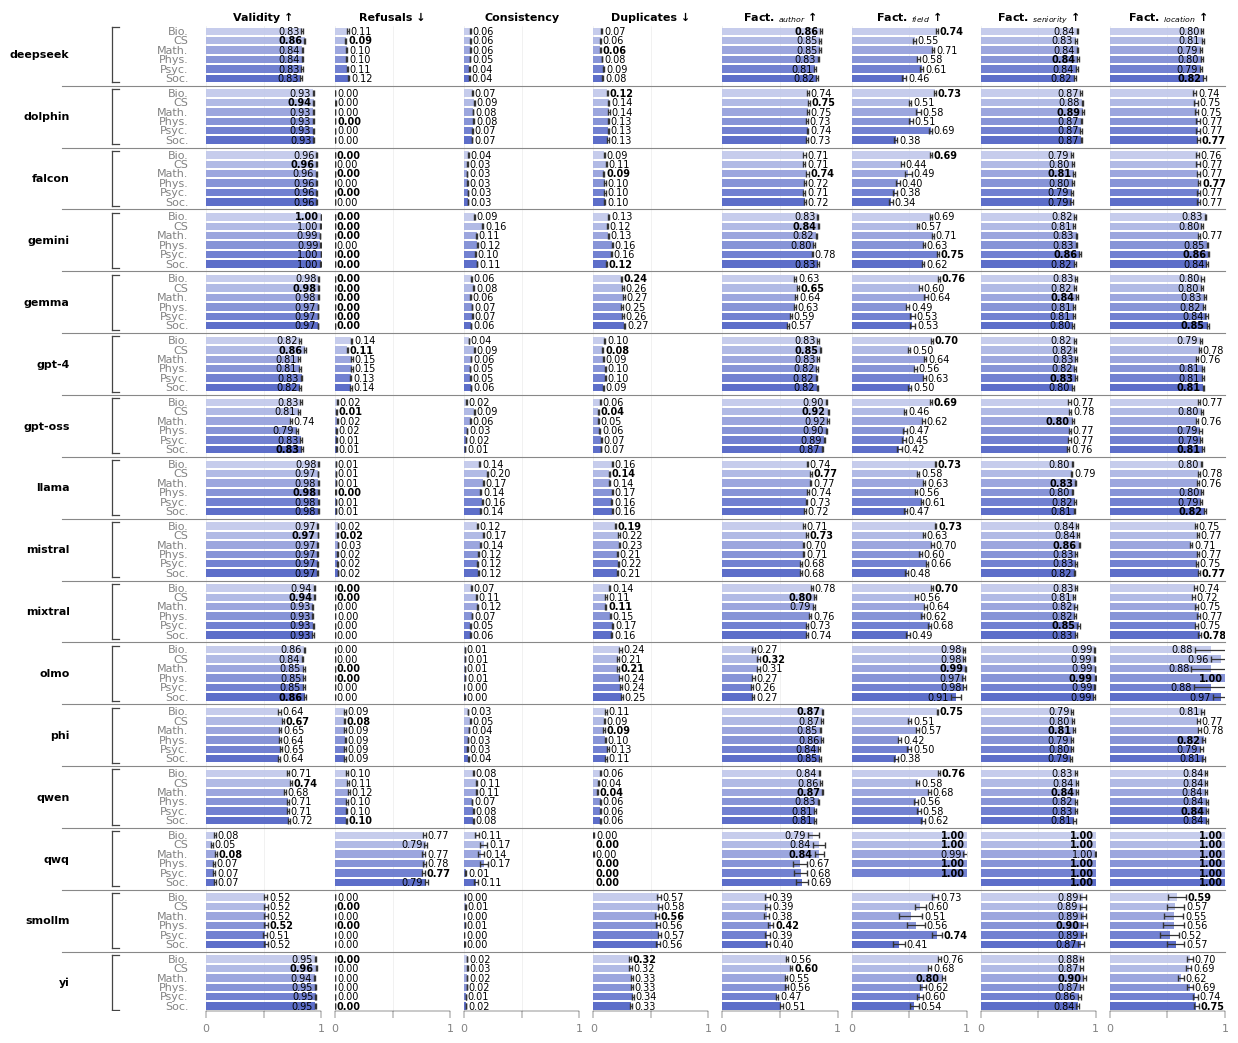

social
/code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_field.pdf
Saved → /code/asanchez/LLMScholar-Personas/results/plots/plot_social_modelfamily_field.pdf


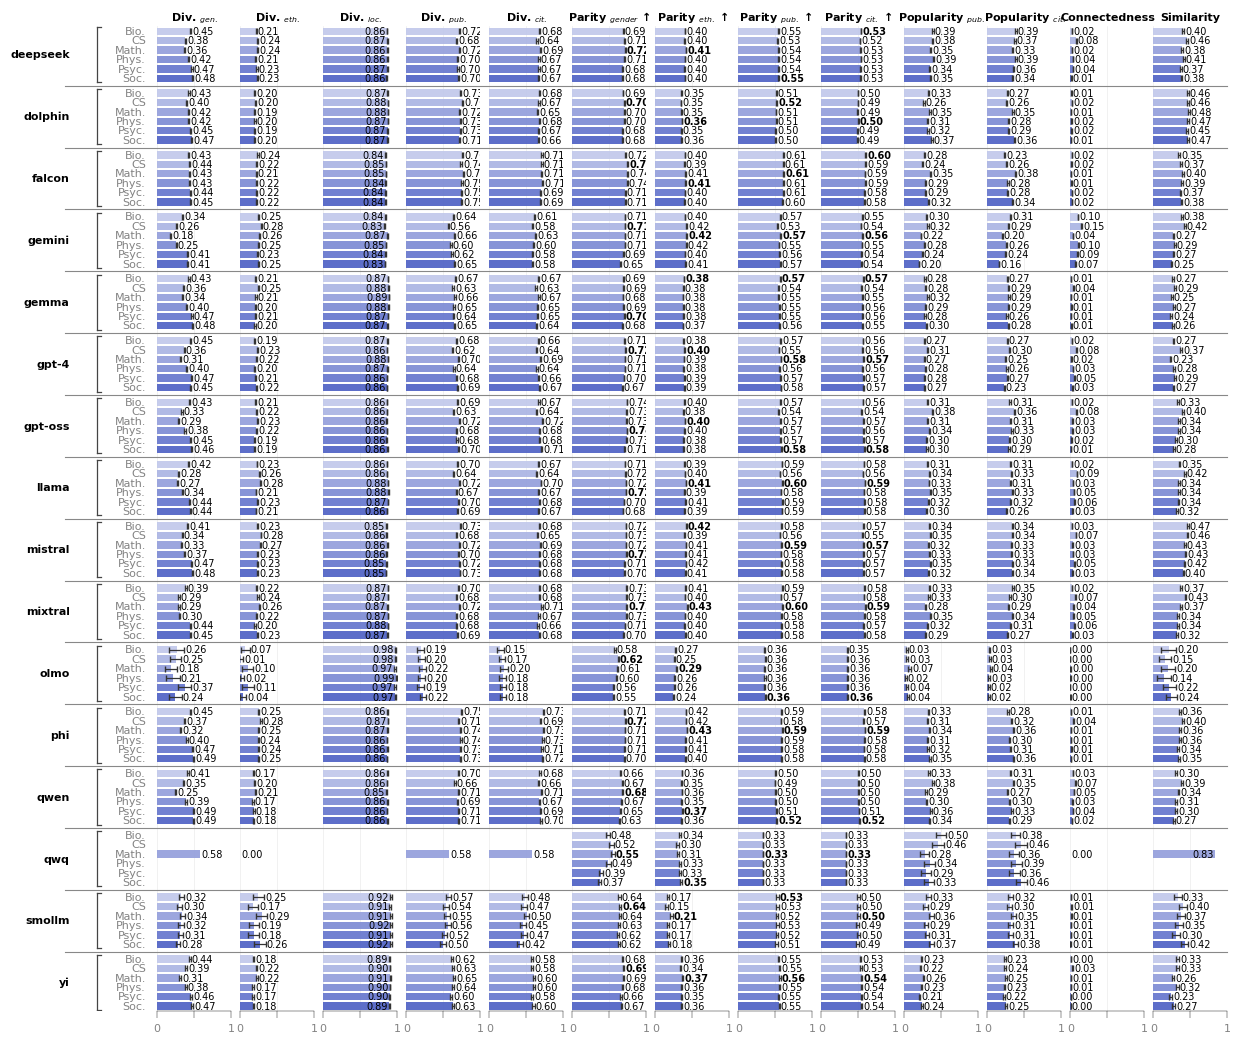

In [35]:
df_modelfamily_lang_field = aggregate_scores(df_valid_calls, ['model_family', 'field_en'])

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_modelfamily_field.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_modelfamily_lang_field,
        group_configs=[
            {'label': model_family, 
             'column': 'field_en', 
             'color': "#4F62C5",
            'filter': {'model_family': model_family}, 
            'order': FIELD_ORDER}
            for model_family in df_modelfamily_lang.model_family.unique()
        ],
        row_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=METRIC_DIRECTIONS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * df_modelfamily_lang.model_family.nunique()),
        textwrap_width = 12
    )

## Structural metrics: connectedness & similarity

Paper Eqs. 6-8. Both are computed over `Û_i`, the unique *factual* authors of a response,
and both are **undefined (NaN) when fewer than 2 of those authors are evaluable** —
connectedness because `log n = 0` at n=1, similarity because there is no pair.

Two structural reasons produce most of the NaNs, and neither is a bug:

1. **`k = 1` can never yield a value.** One recommendation means at most one author, so
   a third of the experiment is NaN by construction.
2. **Authors matched only in Semantic Scholar have no `oa_id`**, hence no graph node and
   no feature vector, so they are excluded and counted (~13% of factual authors).

Use `n_used_*` as the denominator, **not** `n_authors_found`: the latter collapses every
author without an `oa_id` into a single entry, so subtracting the two goes negative.

In [36]:
# Coverage diagnostic: where the NaNs come from, and how the two metrics are distributed.
for m in STRUCTURAL_METRICS:
    s = df_valid_calls[m]
    print(f'{m}: defined for {s.notna().sum():,}/{len(s):,} responses ({100*s.notna().mean():.1f}%)')
    print(f'   mean={s.mean():.4f}  median={s.median():.4f}  '
          f'min={s.min():.4f}  max={s.max():.4f}')

# k=1 is NaN by construction — one recommendation cannot make a pair.
print('\ncoverage by k (share of responses with a defined value):')
display(df_valid_calls.groupby('k')[STRUCTURAL_METRICS]
        .apply(lambda g: g.notna().mean().round(4)))

# n_used is the denominator of Eqs. 6-8; >=2 exactly when the metric is defined.
print('exclusions and denominator:')
_cols = list(STRUCTURAL_EXCLUSION_COLS.values()) + list(STRUCTURAL_USED_COLS.values())
display(df_valid_calls[_cols].describe().loc[['mean', 'max']].round(3))

# The two metrics are only weakly related, so they are not redundant.
_sub = df_valid_calls[STRUCTURAL_METRICS].dropna()
print(f"pearson(connectedness, similarity) = {_sub.corr().iloc[0, 1]:.4f}")

connectedness: defined for 347,036/928,800 responses (37.4%)
   mean=0.0382  median=0.0000  min=0.0000  max=1.0000
similarity: defined for 347,036/928,800 responses (37.4%)
   mean=0.3548  median=0.3653  min=-0.9999  max=1.0000

coverage by k (share of responses with a defined value):


,connectedness,similarity
k,,
1,0.0149,0.0149
5,0.5463,0.5463
10,0.5597,0.5597


exclusions and denominator:


,n_excluded_connectedness,n_excluded_similarity,n_used_connectedness,n_used_similarity
mean,0.4990,0.4990,3.6130,3.6130
max,24.0000,24.0000,37.0000,37.0000


pearson(connectedness, similarity) = 0.2415


## Location flows (Sankey) — issue #37

Where the recommended authors are actually based, given the country embedded in the
prompt. Built from `location_flows.csv` (`scripts/metrics/build_location_flows.py`),
which keeps one row per (prompt country, author country, field, language, model), so
the figure can be sliced without re-reading `factuality_full.csv`.

Each source is normalised to 100%, so ribbon widths read as *"% of times a country R
appears in the recommendations for country C"* — the question the issue asks. Without
normalising, a prompt country with more resolvable authors would look more biased just
for being bigger.

Authors whose OpenAlex record has no country (15.2% of factual recommendations) cannot
enter a flow and are excluded; the tail beyond the top 10 destinations is folded into
`Other` rather than dropped.


In [ ]:
FLOWS_PATH = RESULTS / 'factualities/tables/location_flows.csv'
df_flows = pd.read_csv(FLOWS_PATH)
print(f'Loaded {len(df_flows):,} flow rows | {df_flows.n.sum():,} recommendations')

# ISO-2 on both sides; reuse the repo's per-country colours for the sources.
_iso2name = {v: k for k, v in LLM_COUNTRY_TO_ISO.items() if k in LOCATION_COLORS}
_src_labels = {i: _iso2name.get(i, i) for i in df_flows.src_iso.unique()}
_src_colors = {i: LOCATION_COLORS[_iso2name[i]]
               for i in df_flows.src_iso.unique() if i in _iso2name}

_agg = df_flows.groupby(['src_iso', 'dst_iso'], as_index=False).n.sum()
_agg = collapse_tail(_agg, target_col='dst_iso', value_col='n', top_n=10)
_agg = normalize_by_source(_agg, source_col='src_iso', value_col='n')

_order = _agg.groupby('dst_iso').n.sum().sort_values(ascending=False).index.tolist()
_order = [d for d in _order if d != 'Other'] + ['Other']
_dst_labels = {d: COUNTRY_ISO_NAMES.get(d, d) for d in _order}

fig, ax = plot_sankey(
    _agg,
    source_col='src_iso', target_col='dst_iso', value_col='n',
    source_order=[i for i in LOCATION_ISO_ORDER if i in set(_agg.src_iso)],
    target_order=_order,
    source_colors=_src_colors,
    source_labels=_src_labels,
    target_labels=_dst_labels,
    figsize=(10, 8), value_fmt='{pct:.1f}%', node_gap=0.015,
)
ax.set_title('Country of recommended authors, by country embedded in the prompt\n'
             '(each source normalised to 100%)', fontsize=12, pad=16)

fn = str(PLOTS_DIR / 'plot_location_sankey.pdf')
fig.savefig(fn, dpi=FIG_DPI, bbox_inches='tight', facecolor='white')
print(fn)
plt.show()
plt.close()
